<a href="https://colab.research.google.com/github/thx1173/git_zadania/blob/main/Grupa_4_DataPreprocessing_i_analiza_danych.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data Preprocessing + Analiza i wizualizacja danych . dr inż. Karol Flisikowski.**

Ćwiczenie zaliczeniowe. Grupa4: Andrzej Zieliński.

Z uwagi na brak kontaktu z pozostałymi członkami grupy i zaplanowany wyjazd nad zadaniem pracowałem samodzielnie.

Baza danych: apartments_rent_pl_2023_12.csv


Celem zadania jest kontynuacja i rozszerzenie zadania zaliczeniowego z przedmiotu **Data Preprocesing** obejmującego przygotowanie "surowych danych" do analizy, o kolejne kroki związane z analizę i wizualizację danych z wykorzystaniem bibliotek *Seaborn* oraz *Matplotlib*.
Jest to zadanie zaliczeniowe w ramach przedmioty: **Analiza opisowa i wizualizacja danych w Python.**

Przyjetą zmienną zależaą, która w dalszej perspektywie będzie podlegała analizie jest cena 'price'.

### W pierwszym kroku importujemy wszystkie niezbędne biblioteki python

In [55]:
import seaborn as sns
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt



Następnie wczytujemy plik danych dotyczących apartamentów do wynajęcia z pliku csv: apartments_rent_pl_2023_12.csv zawierający dane obejmujące wszystkie miasta w danym miesiącu.

Poddamy analizie dane dotyczące wynajęcia apartamentów w Warszawie w **grudniu 2023.**

In [56]:

df_all = pd.read_csv('https://raw.githubusercontent.com/kflisikowsky/analiza_danych_projekt_zespolowy/refs/heads/main/Nieruchomosci%20w%20Polsce/apartments_rent_pl_2023_12.csv')
df_all

,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,pharmacyDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,c63a4bfb4e073634d5d2841eff4448d4,szczecin,NaN,65.00,2.0,3.0,4.0,NaN,53.428544,14.552812,...,0.085,condominium,NaN,NaN,no,no,no,no,no,2200
1,98ee431da834e6c7944b315f39ee7846,szczecin,blockOfFlats,43.04,2.0,4.0,4.0,1965.0,53.434000,14.551800,...,0.116,condominium,NaN,NaN,yes,yes,no,no,no,2100
2,2a1a6db97ff122d6bc148abb6f0e498a,szczecin,blockOfFlats,52.00,2.0,3.0,3.0,2008.0,53.460535,14.545416,...,0.307,condominium,brick,NaN,yes,yes,no,no,no,3500
3,693e851f34d2f621e8b458517ce4a6df,szczecin,blockOfFlats,40.00,2.0,1.0,5.0,NaN,53.417761,14.542467,...,0.220,condominium,NaN,premium,yes,yes,yes,yes,no,2350
4,a6947320455a7f8afd2d53497a5b47e9,szczecin,blockOfFlats,70.00,3.0,1.0,2.0,2000.0,53.442188,14.486052,...,0.273,condominium,brick,NaN,yes,no,no,no,no,3200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8867,e9c0f3ca8fd42bc4c8b07ef2a5c53d2e,bydgoszcz,tenement,53.00,3.0,1.0,4.0,NaN,53.126000,18.007900,...,0.205,condominium,brick,NaN,no,no,no,no,no,2190
8868,89fdf9ecda6fe6aa95e34528fa82f55f,bydgoszcz,blockOfFlats,48.00,2.0,3.0,3.0,2019.0,53.121200,17.992500,...,0.300,condominium,brick,NaN,no,no,no,no,no,2700
8869,095b187d0bbce092d4b03164e89710c5,bydgoszcz,blockOfFlats,50.00,2.0,1.0,3.0,2019.0,53.121200,17.992500,...,0.300,condominium,brick,NaN,no,yes,no,no,no,2800
8870,eee39c309b4f55e057485d848bb2772b,bydgoszcz,NaN,40.00,2.0,1.0,1.0,NaN,53.126000,18.007900,...,0.205,condominium,NaN,NaN,no,no,NaN,no,no,1500


Info na temat pliku danych z wszystkimi miastami. Nas docelowo będzie interesowała tylko Warszawa.

In [57]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8872 entries, 0 to 8871
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    8872 non-null   object 
 1   city                  8872 non-null   object 
 2   type                  6559 non-null   object 
 3   squareMeters          8872 non-null   float64
 4   rooms                 8872 non-null   float64
 5   floor                 7790 non-null   float64
 6   floorCount            8660 non-null   float64
 7   buildYear             6190 non-null   float64
 8   latitude              8872 non-null   float64
 9   longitude             8872 non-null   float64
 10  centreDistance        8872 non-null   float64
 11  poiCount              8872 non-null   float64
 12  schoolDistance        8870 non-null   float64
 13  clinicDistance        8864 non-null   float64
 14  postOfficeDistance    8868 non-null   float64
 15  kindergartenDistance 

Następonie z całego DataFrame *df_all* filtrujemy i wycinamy tylko wiersze, które dotyczą apartamentów zlikolizowanych w __Warszawie__ i dokonujemy ich reindeksacji aby uporządkować numerację wierszy.

In [58]:
df_wawa = df_all[df_all['city'] == 'warszawa']
df_wawa = df_wawa.reset_index(drop=True)
df_wawa.head(15)

,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,pharmacyDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,66c8701beef1ffbba137456cef6b5271,warszawa,tenement,39.80,2.0,2.0,3.0,1939.0,52.216513,21.041474,...,0.948,condominium,brick,NaN,no,no,no,no,no,3650
1,795467e61dfb1e7a60e1936ec8354024,warszawa,apartmentBuilding,78.00,3.0,6.0,15.0,2008.0,52.245300,20.977900,...,0.184,condominium,brick,NaN,yes,yes,yes,no,no,5600
2,56a0cb47391eb1ad4d3e37c07d67d10d,warszawa,tenement,82.00,3.0,3.0,4.0,1875.0,52.229151,20.990837,...,0.132,condominium,brick,NaN,no,no,NaN,no,no,6500
3,5951272b96c6d81b8358a19c744c785f,warszawa,blockOfFlats,89.00,4.0,3.0,3.0,2000.0,52.322375,20.937528,...,0.283,condominium,brick,NaN,yes,no,no,yes,yes,4500
4,05c77ee5f6049988bac5cb9af797a78d,warszawa,NaN,45.23,2.0,2.0,3.0,NaN,52.238990,21.076190,...,0.129,condominium,NaN,NaN,no,yes,no,no,no,3000
5,d1e1325b65f4255251cac39f2d2e3d34,warszawa,tenement,50.00,3.0,1.0,3.0,1932.0,52.225329,21.034436,...,0.147,condominium,brick,NaN,no,yes,no,no,no,3750
6,3097935210f8cca2ef7dde8ae54d023d,warszawa,NaN,70.00,3.0,1.0,3.0,2003.0,52.201553,20.958403,...,0.152,condominium,NaN,NaN,yes,yes,yes,no,no,4500
7,21e869e0c9ec0773a44acbda19a9d297,warszawa,NaN,68.00,3.0,NaN,3.0,1903.0,52.252914,21.033938,...,0.014,condominium,NaN,NaN,no,no,no,no,no,5000
8,7642e109f1929a86473dfd010d2f5545,warszawa,NaN,79.00,3.0,9.0,12.0,2009.0,52.207391,20.964526,...,0.066,condominium,NaN,NaN,yes,yes,yes,no,no,5900
9,5f9d93e45bad91a55f42b871b329ae68,warszawa,NaN,62.00,3.0,4.0,6.0,2016.0,52.227043,20.955604,...,0.108,condominium,NaN,NaN,yes,yes,yes,no,no,5000



Info na temat pliku danych obejmująych tylko Warszawę.

Nasze dane wejściowe do dalszej oceny to **3575 wierszy**

In [59]:
df_wawa.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3575 entries, 0 to 3574
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    3575 non-null   object 
 1   city                  3575 non-null   object 
 2   type                  2436 non-null   object 
 3   squareMeters          3575 non-null   float64
 4   rooms                 3575 non-null   float64
 5   floor                 3221 non-null   float64
 6   floorCount            3523 non-null   float64
 7   buildYear             2596 non-null   float64
 8   latitude              3575 non-null   float64
 9   longitude             3575 non-null   float64
 10  centreDistance        3575 non-null   float64
 11  poiCount              3575 non-null   float64
 12  schoolDistance        3575 non-null   float64
 13  clinicDistance        3575 non-null   float64
 14  postOfficeDistance    3575 non-null   float64
 15  kindergartenDistance 

Widać, że dane w kolumnie 'id' to tylko losowy ciąg znaków i nie będą potrzebne w dalszej analizie.

Usuwamy tą kolumnę.

In [60]:
df_wawa = df_wawa.drop('id', axis='columns')
df_wawa



,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,...,pharmacyDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,warszawa,tenement,39.80,2.0,2.0,3.0,1939.0,52.216513,21.041474,3.09,...,0.948,condominium,brick,NaN,no,no,no,no,no,3650
1,warszawa,apartmentBuilding,78.00,3.0,6.0,15.0,2008.0,52.245300,20.977900,2.31,...,0.184,condominium,brick,NaN,yes,yes,yes,no,no,5600
2,warszawa,tenement,82.00,3.0,3.0,4.0,1875.0,52.229151,20.990837,0.91,...,0.132,condominium,brick,NaN,no,no,NaN,no,no,6500
3,warszawa,blockOfFlats,89.00,4.0,3.0,3.0,2000.0,52.322375,20.937528,11.04,...,0.283,condominium,brick,NaN,yes,no,no,yes,yes,4500
4,warszawa,NaN,45.23,2.0,2.0,3.0,NaN,52.238990,21.076190,5.01,...,0.129,condominium,NaN,NaN,no,yes,no,no,no,3000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3570,warszawa,apartmentBuilding,106.00,4.0,2.0,7.0,NaN,52.188264,21.054159,5.94,...,0.298,condominium,brick,NaN,no,no,yes,no,no,6500
3571,warszawa,apartmentBuilding,90.00,3.0,1.0,8.0,NaN,52.186439,21.052592,6.04,...,0.162,condominium,brick,NaN,no,yes,yes,no,no,6500
3572,warszawa,NaN,122.00,5.0,3.0,3.0,NaN,52.163853,21.077093,9.06,...,0.190,condominium,NaN,premium,no,yes,yes,no,no,12000
3573,warszawa,apartmentBuilding,148.00,6.0,1.0,3.0,NaN,52.186263,21.030013,5.37,...,0.552,condominium,brick,premium,no,yes,yes,no,no,12500


Aby potwierdzić, w których kolumnach występują braki danych wykorzystamy metode .isna() z dodatkowym aparametrem .any(). Ta funkcja wskaże, w ktorej kolumnie brakuje danych (True), a gdzie dane są kompletne (False).

Jak widać w pliku danych w 11 kolumnach są braki danych (NaN)

In [61]:
df_wawa.isna().any()

,0
city,False
type,True
squareMeters,False
rooms,False
floor,True
floorCount,True
buildYear,True
latitude,False
longitude,False
centreDistance,False


Aby określić dokładnie ilość brakujących danych w poszczególnych kolumnach zliczymy ilość NaN w kazdej z nich

In [62]:
df_wawa.isna().sum()

,0
city,0
type,1139
squareMeters,0
rooms,0
floor,354
floorCount,52
buildYear,979
latitude,0
longitude,0
centreDistance,0


Aby zwizualizować ilość brakujących danych (NaN) wykorzystamy ich prezentację graficzną na wykresie słupkowym z wykorzystaniem biblioteki missingno.

Wykres słupkowy prezentuje jak kompletna jest ilość danych w każdej kolumnie w stosunku do ilości maksymalnej równej ilosci wierszy w ramce danych - w naszym przypadku max ilośc danych w kolumnie  to 3575)



Na podstawie wykresu widać, że z 11 kolumn z brakującymi danymi największy udytek danych jest w kolumnie 'condition' = 2833.

Sporo danych jest również pominietych w kolumnach: 'type' = 1139, 'buid year' = 978, 'building material'  = 1460.

W toku dalszej analizy zdecydujemy "czy" i "jak" będziemy uzupełniać te dane.

<Axes: >

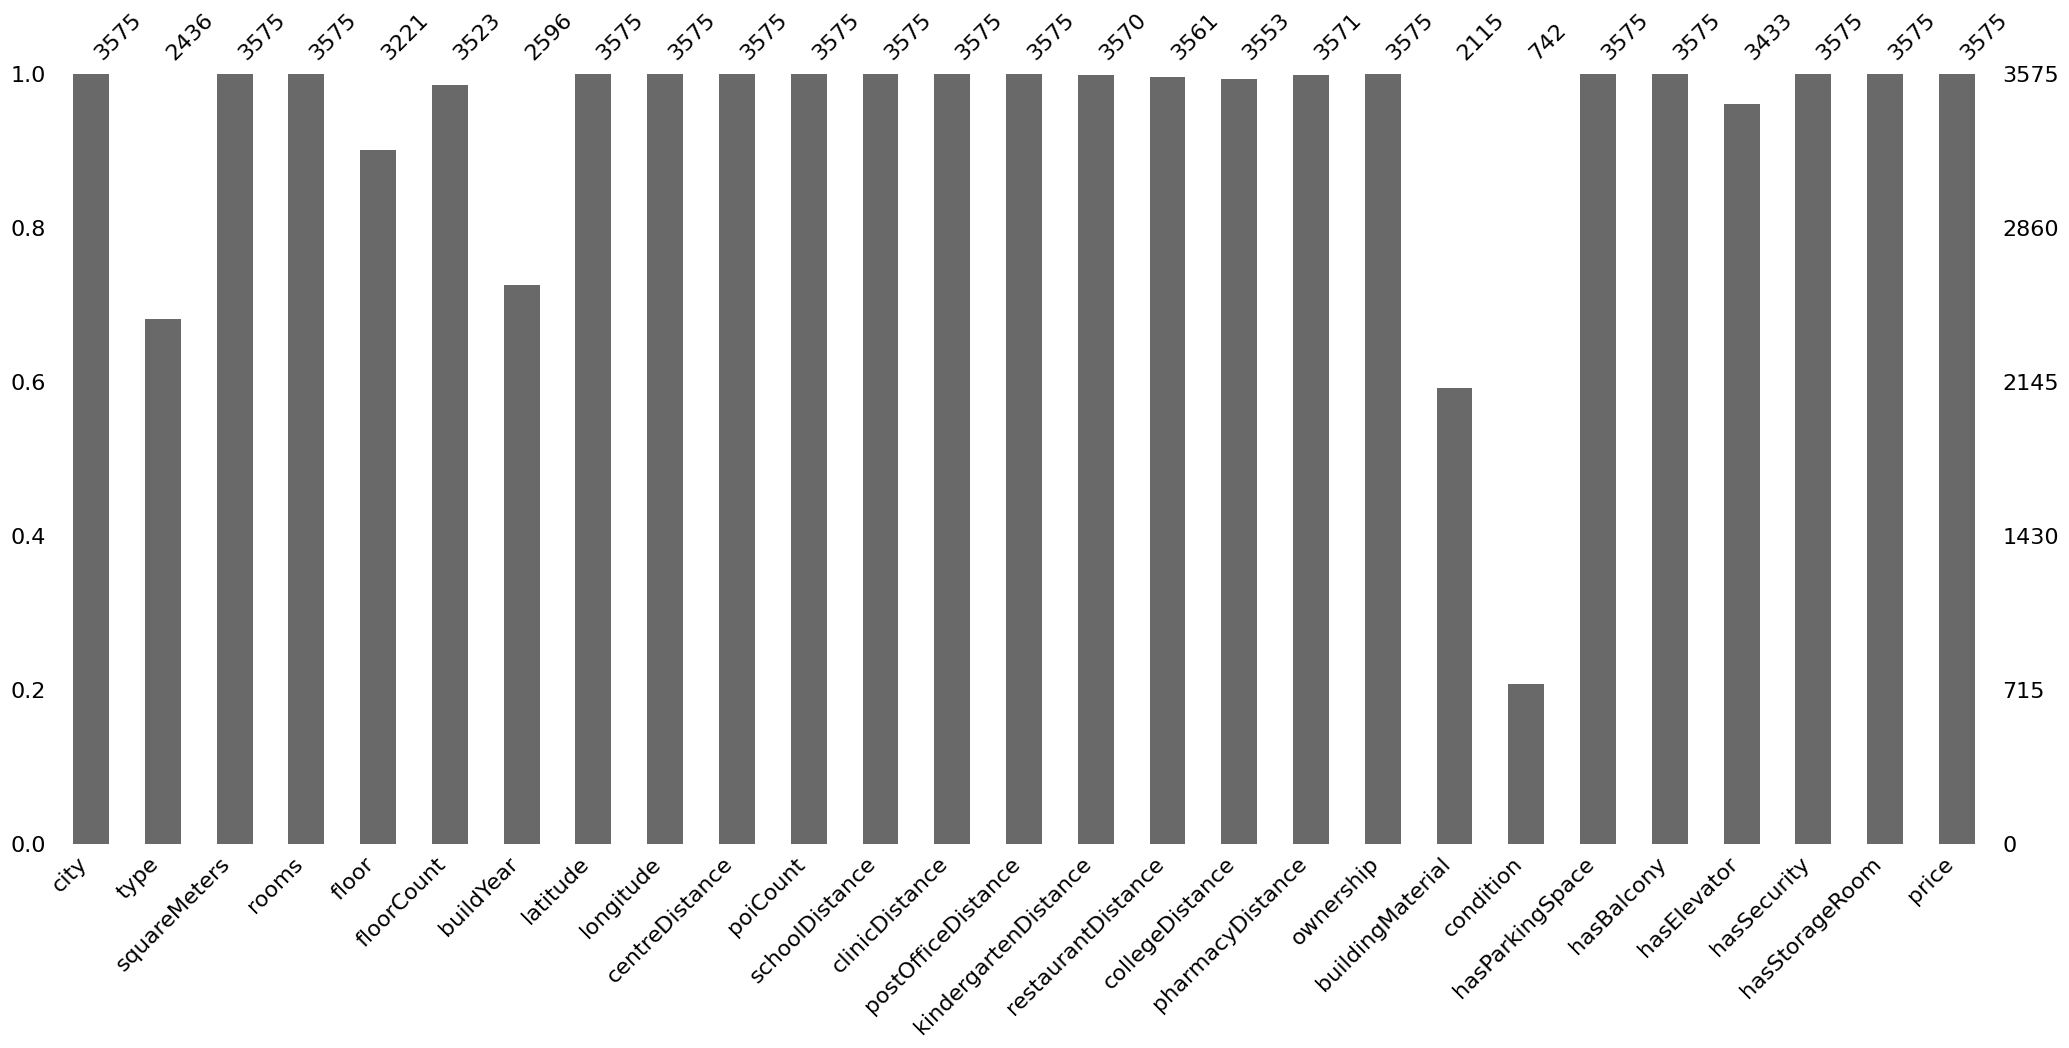

In [63]:
msno.bar(df_wawa)

Kolejny krok to graficzna reprezentacaj rozłożeia brakujących danych.
W pierwszej kolejności wykorzystamy z wykresu matrix biblioteki missingno


Na tej podstawie można zauważyć, że duży ubytek danych w 4 ww. seriach daych (kolumnach). Ich rozkład jest raczej przypadkowy i w kolejnych krokach analizy należy poszukać ewentualnych korelacji między nimi.

Na podstawie wykresu ze skrajnej prawej strony można odczytać, ze minimalna ilość danych w wierszu danych to 19.

<Axes: >

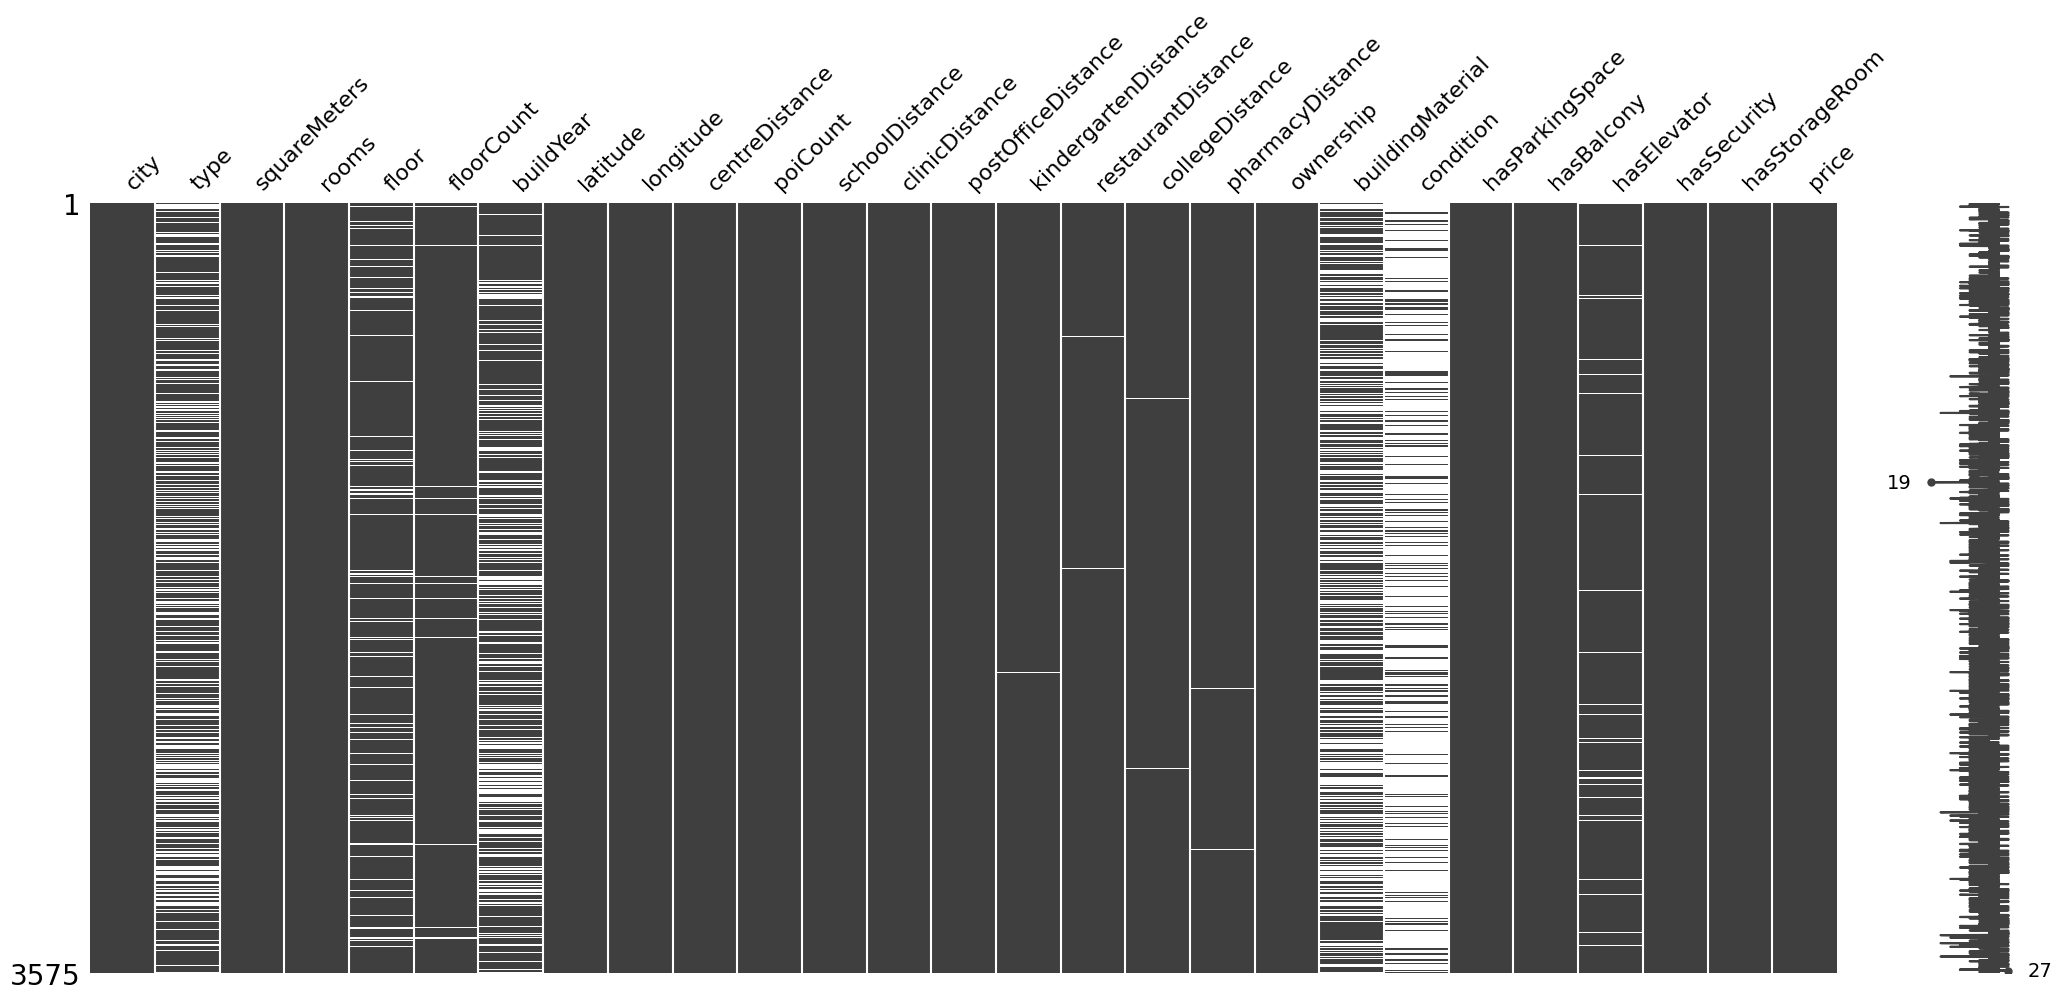

In [64]:
msno.matrix(df_wawa)


Kolejny krok to graficzna prezentacja korelacji pomiędzy brakującymi danymi w kolumnach. Analiza korelacji danych została wykonana z wykorzystaniem "mapy ciepła" z biblioteki missingno, która analizuje wzajemną korelację analizowanych cech.


Mapę ciepła wygenerujemy za pomocom polecenia: msno.heatmap(df_wawa)


Podstawie mapy ciepła widać silną korelację pomiędzy brakiem danych (NaN) pomiedzy "buildingMaterial" oraz "type". A także zauważalną korelacje braku danych pomiędzy: "build year" oraz "type", "flor Count" oraz "flor"i w końcu pomiedzy "buildYear" oraz "buildMaterial".

Można założyć, z osoby wynajmujące apartament celowo nie publikują, brak ww. danych, bo mogły by one wskazywać, że apartament jest już "wiekowy", zbudowany w starej technologii a co się z tym wiąże jego typ ciężko jest zakwalifikować do najczęściej używanych typów lokali.

Dodatkowo brak danych o ilość pięter w stosunku do ilości pięter w budynku może wskazywać na położenie na wyższych kondygnacjach lub na poddaszu. Co dodatkowo może wskazuje na korelację z brakiem danych dotyczących typu apartamentu.

<Axes: >

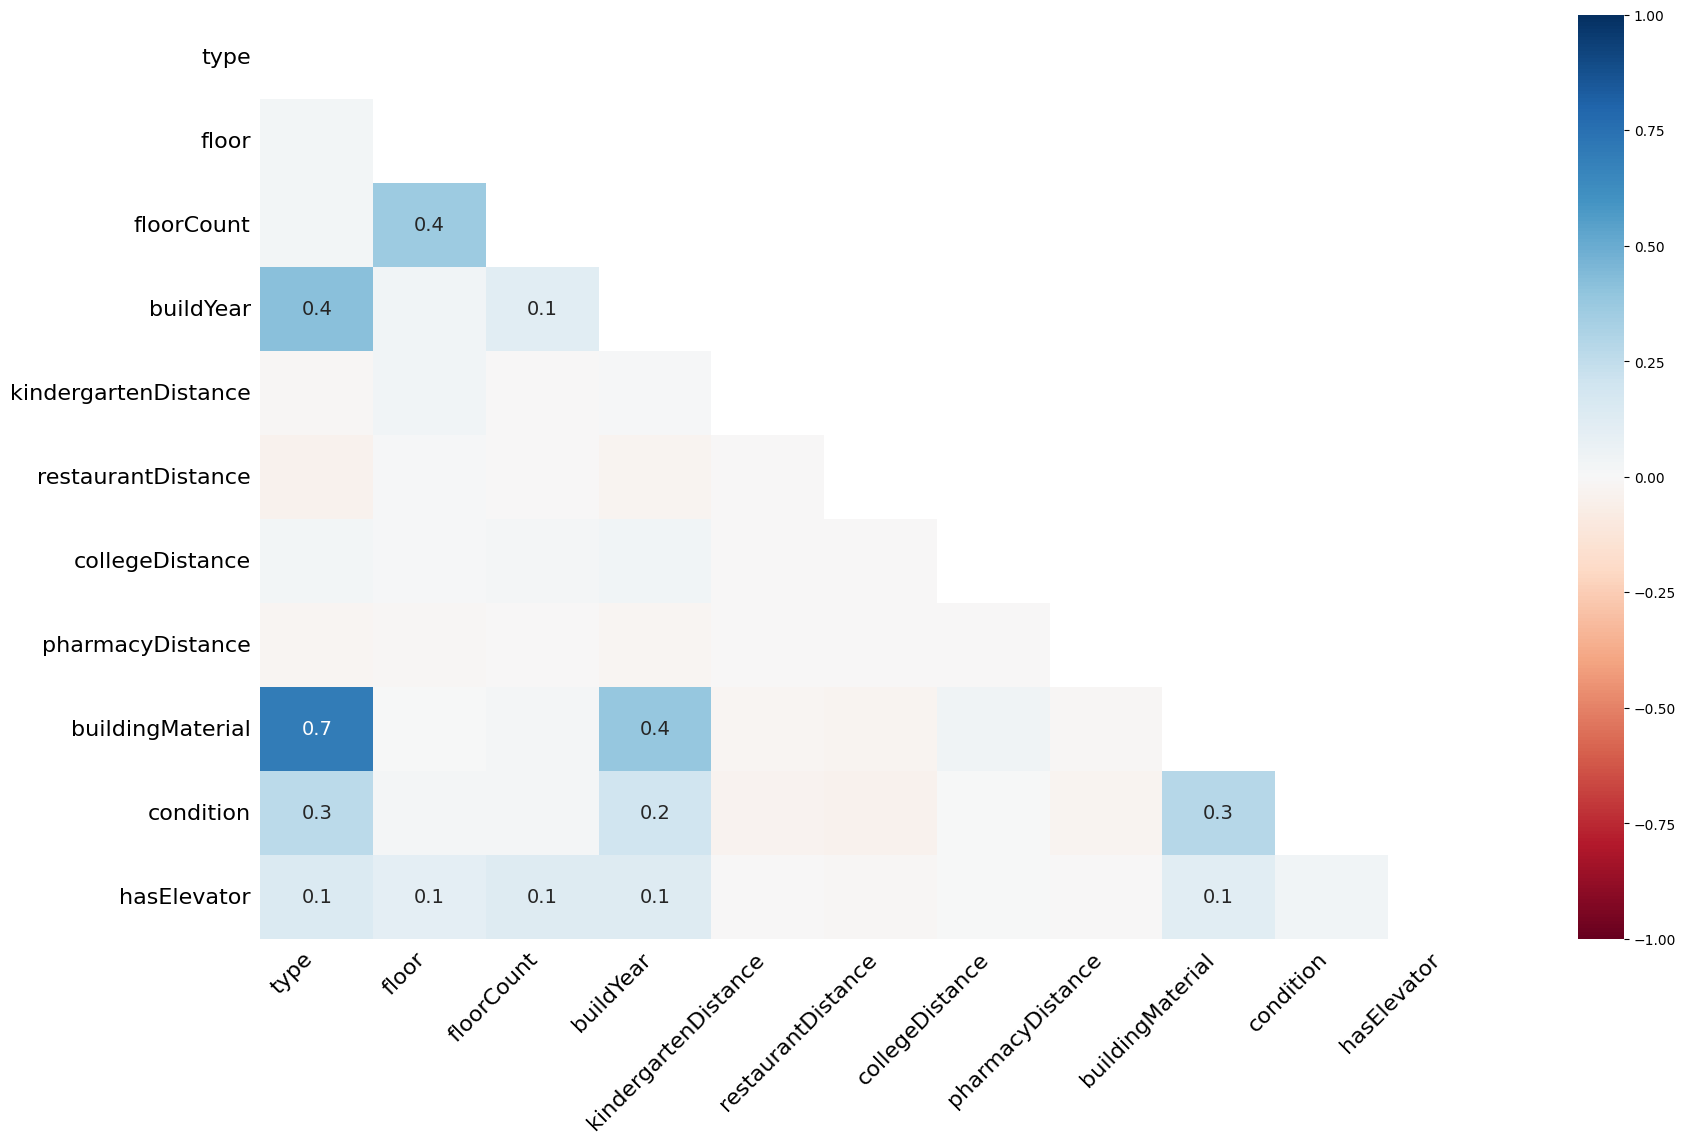

In [65]:
msno.heatmap(df_wawa)


Ostatnim wykresem badającym korelację braku danych w pakiecie missingno jest **dedrogram**, który grupuje kolumny o silnych korelacjach wartosci NaN.

<Axes: >

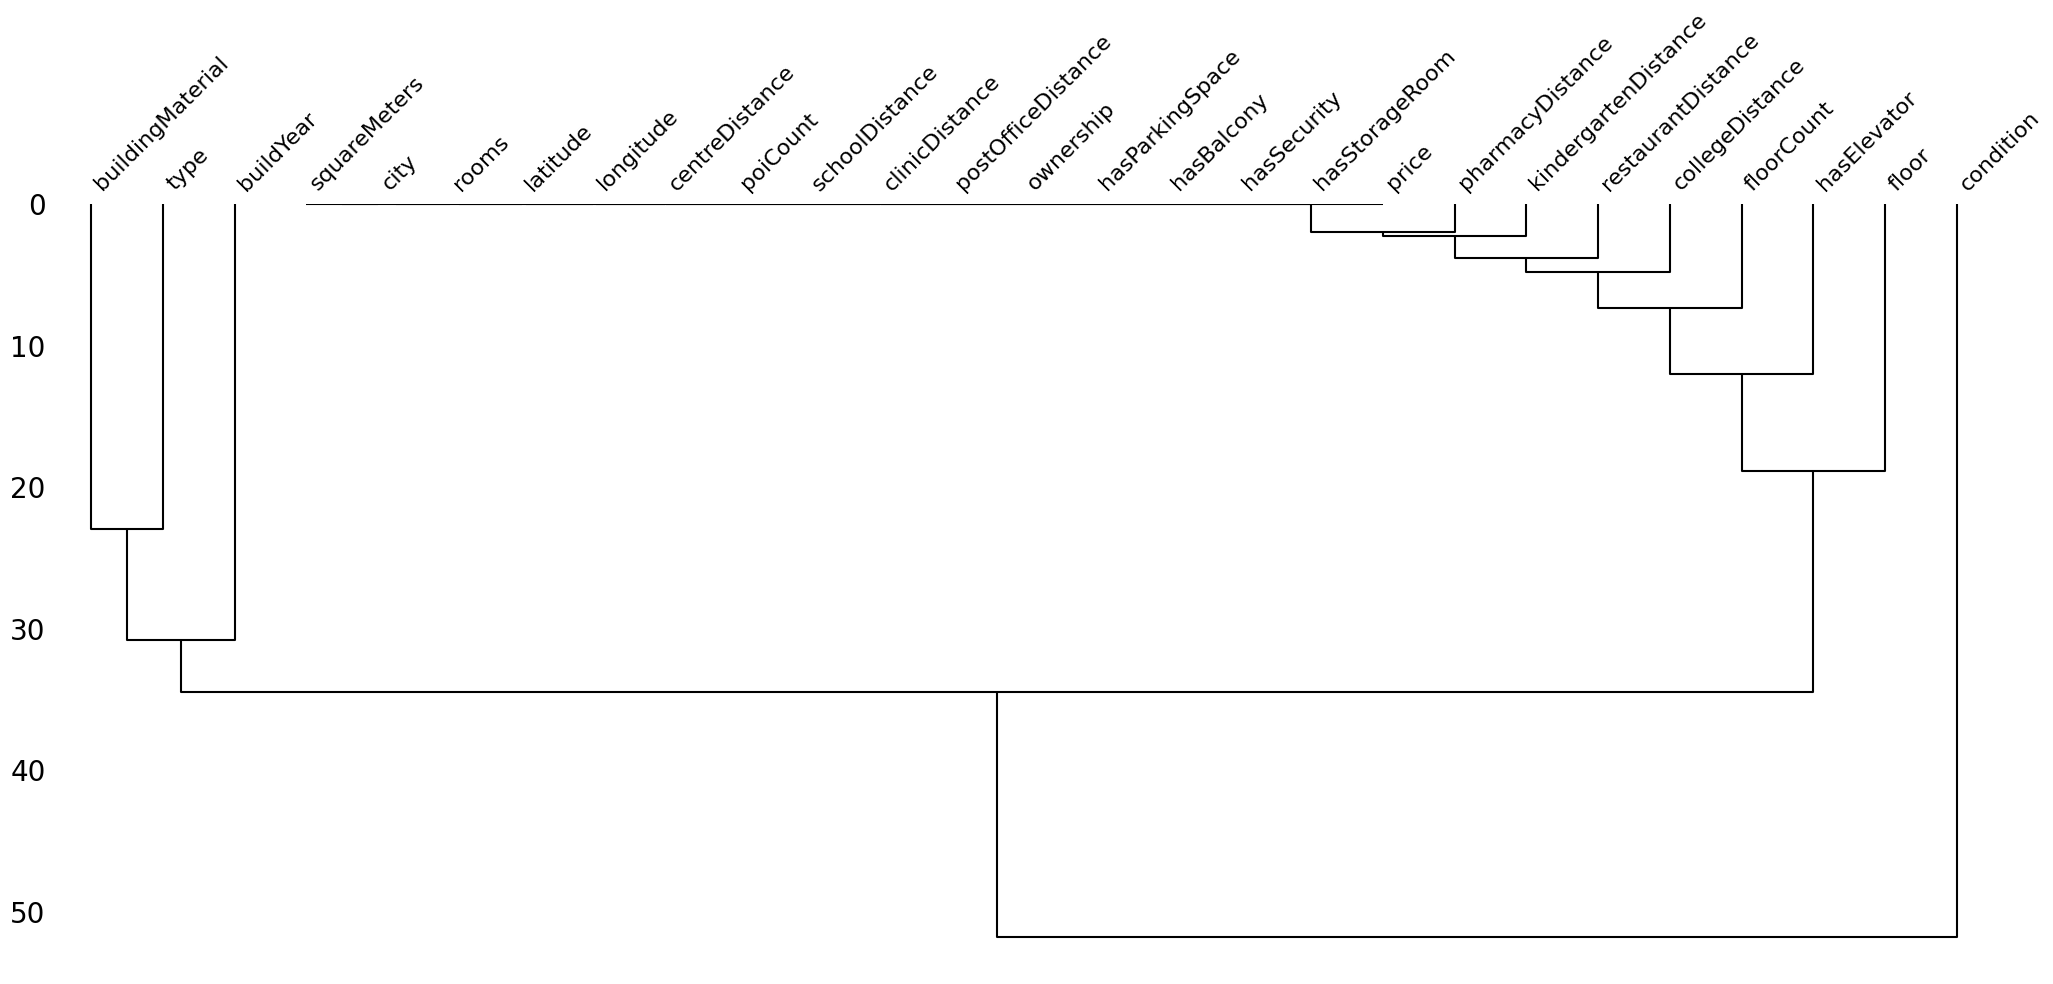

In [66]:
msno.dendrogram(df_wawa)

### Dendrogram jest wyraźnie podzielony na **5 odrebnych stref**, siłę korelacji odczytujemy od wartosci 0:

**1. strefa** (od 'squareMeters' do 'price')  jest oparta o wartość 0, zawiera
kompletne dane, co oczywiście zapewnia silną korelację pomiędzy nimi.

**2. strefa** (od 'buildingMaterial' do 'buildYear') tworzą rdzeń problemu. Mają najwyższe braki (10–40%) i najsilniejsze korelacje (0.3–0.7). Ogłoszeniodawca pomija opis fizyczny budynku, co może sugerować, że nie jest on atrakcyjny.

**3. strefa** (od 'pharmacyDistance' do 'collegeDistance') Skupienie w dendrogramie wynika z podobnego, bardzo niskiego poziomu braków (wykres bar: ~0,5–1,5%), a nie z prawdziwej korelacji braków. Skupiają się w drzewie, bo są podobnie pełne nie dlatego, że brakuje im wspólnych danych. Heatmapa potwierdza: brak korelacji braków między nimi.

**4. strefa** (od 'florCount' do 'flor') mają korelację 0.4 przy niedużych brakach (~10% i <1%). Brak numeru piętra często idzie w parze z brakiem liczby pięter w budynku — logicznie spójne. Może też wskazywać, ze wynajmujący nie chce wskazywać, że apartament jest na wyższych piętrach, choć brak silnej korelacji z hasElevator (0.1)

**5. strefa** ('condition') zawiera najmniejszą ilość danych (742) co wyraźnie wskazuje, że ogłoszeniodawcy niechętnie okreslają stan apartamentu a formularz pozwala na taką dowolność. Z dendrogramu wynika, że ta cech nie koreluje z innymi cechami ale mapa ciepła wskazuje na niską korelację z buildingMaterial (0.3) i buildYear (0.2).

###**Wnioski:**

Trzy wykresy razem wskazują na jeden dominujący problem: **opis fizyczny nieruchomości**.

W danych dotyczących: ,   

*   *buildingMaterial* brakuje ~41% rekordów
*   *type* brakuje ~32%
*   *buildYear* brakuje ~27%,
*   flor brakuje ~10%,
*   i wreszcie w *condition* brakuje aż w ~79%.

Heatmapa potwierdza, że te braki są mocno powiązane: korelacja 0.7 między *buildingMaterial* a *type*, korelacja 0.4 między *buildingMaterial* a *buildYear* oraz korelacja 0.4 między *buidYear* a *type*.


To ogłoszeniodawcy — a nie system — pomijają te dane, prawdopodobnie dlatego, że formularz pozwala na ich pominięcie oraz że sami ich nie znają lub nie chcą te dane publikować, bo mogłyby wskazywać na zły stan budynku (np. że jest stary).



###**Rekomendacje do usunięcie Nan i imputacji danych**

1. *condition* — 79% braków to za dużo na standardową imputację. Zmienna zostaje usunięta z analizy.

2. *type* oraz *squareMeters* - squareMeters zawiera 100% danych zbadamy zależność pomiędzy tymi danymi.

3. *type* oraz *buildingMaterial* — korelacja 0.7 umożliwia imputację wzajemną (jeśli znane jest jedno, można przewidzieć drugie) oraz Imputacja Hot Deck najbliższego sąsiedztwa.

4. *buildYear* — imputacja mediany grupowanej z uwzględnieniem 'type' mieszkania.

5. *floor* oraz *floorCount* —  zastosujemy imputację kolumny 'flor' wartoscią średnią z 'florCount' z ograniczeniem 'floor' ≤ 'floorCount'.

Pozostałe kolumny — brak działań, dane praktycznie kompletne lub znikomy ubytek danych.

###1. Usunięcie kolumny condition

In [67]:
df_wawa = df_wawa.drop('condition', axis='columns')
df_wawa.head(15)

,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,...,collegeDistance,pharmacyDistance,ownership,buildingMaterial,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,warszawa,tenement,39.80,2.0,2.0,3.0,1939.0,52.216513,21.041474,3.09,...,1.635,0.948,condominium,brick,no,no,no,no,no,3650
1,warszawa,apartmentBuilding,78.00,3.0,6.0,15.0,2008.0,52.245300,20.977900,2.31,...,0.569,0.184,condominium,brick,yes,yes,yes,no,no,5600
2,warszawa,tenement,82.00,3.0,3.0,4.0,1875.0,52.229151,20.990837,0.91,...,1.237,0.132,condominium,brick,no,no,NaN,no,no,6500
3,warszawa,blockOfFlats,89.00,4.0,3.0,3.0,2000.0,52.322375,20.937528,11.04,...,1.414,0.283,condominium,brick,yes,no,no,yes,yes,4500
4,warszawa,NaN,45.23,2.0,2.0,3.0,NaN,52.238990,21.076190,5.01,...,0.264,0.129,condominium,NaN,no,yes,no,no,no,3000
5,warszawa,tenement,50.00,3.0,1.0,3.0,1932.0,52.225329,21.034436,2.22,...,1.111,0.147,condominium,brick,no,yes,no,no,no,3750
6,warszawa,NaN,70.00,3.0,1.0,3.0,2003.0,52.201553,20.958403,4.55,...,1.580,0.152,condominium,NaN,yes,yes,yes,no,no,4500
7,warszawa,NaN,68.00,3.0,NaN,3.0,1903.0,52.252914,21.033938,3.14,...,0.522,0.014,condominium,NaN,no,no,no,no,no,5000
8,warszawa,NaN,79.00,3.0,9.0,12.0,2009.0,52.207391,20.964526,3.79,...,0.839,0.066,condominium,NaN,yes,yes,yes,no,no,5900
9,warszawa,NaN,62.00,3.0,4.0,6.0,2016.0,52.227043,20.955604,3.31,...,0.688,0.108,condominium,NaN,yes,yes,yes,no,no,5000


###2. Badamy korelacje danych pomiędzy 'type' a 'squareMeters'.

Do badania korelacji przyjęto medianę z uwagi na fakt, że jest odporniejsza na wartości odstające.

<Axes: xlabel='type', ylabel='squareMeters'>

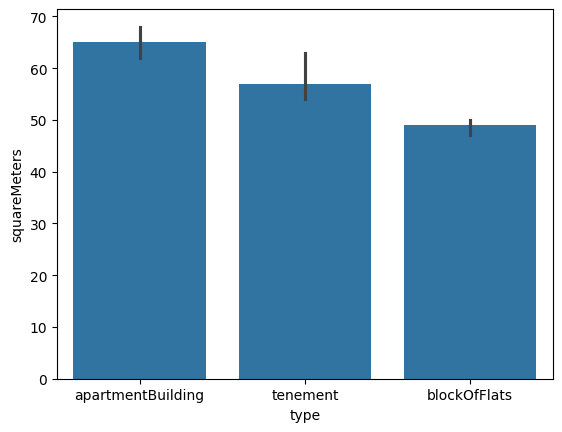

In [68]:
sns.barplot(data = df_wawa, x = 'type', y = 'squareMeters', estimator="median", order=('apartmentBuilding', 'tenement','blockOfFlats'))


Na podstawie ww. wykresów zdecydowano o imputacji zależnej pomiedzy *type* a *squareMeters*, wg zależności:


*   apartmentBuilding, gdy squareMeters >= 60
*   tenement, gdy 40 =< squareMeters < 60
*   blockOfFlats, gdy 00 < squareMeters < 40

Realizowane w trzech krokach:






In [69]:
# warunek 1: type jest NaN i squareMeters >= 60
df_wawa.loc[df_wawa['type'].isna() & (df_wawa['squareMeters'] >= 60), 'type'] = 'apartmentBuilding'

# warunek 2: type jest NaN i 40 <= squareMeters < 60
df_wawa.loc[df_wawa['type'].isna() & (df_wawa['squareMeters'] >= 40) & (df_wawa['squareMeters'] < 60), 'type'] = 'tenement'

# warunek 3: type jest NaN i 0 < squareMeters < 40
df_wawa.loc[df_wawa['type'].isna() & (df_wawa['squareMeters'] > 0) & (df_wawa['squareMeters'] < 40), 'type'] = 'blockOfFlats'

#print(df_wawa['type'].isna().sum())
df_wawa.head(15)




,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,...,collegeDistance,pharmacyDistance,ownership,buildingMaterial,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,warszawa,tenement,39.80,2.0,2.0,3.0,1939.0,52.216513,21.041474,3.09,...,1.635,0.948,condominium,brick,no,no,no,no,no,3650
1,warszawa,apartmentBuilding,78.00,3.0,6.0,15.0,2008.0,52.245300,20.977900,2.31,...,0.569,0.184,condominium,brick,yes,yes,yes,no,no,5600
2,warszawa,tenement,82.00,3.0,3.0,4.0,1875.0,52.229151,20.990837,0.91,...,1.237,0.132,condominium,brick,no,no,NaN,no,no,6500
3,warszawa,blockOfFlats,89.00,4.0,3.0,3.0,2000.0,52.322375,20.937528,11.04,...,1.414,0.283,condominium,brick,yes,no,no,yes,yes,4500
4,warszawa,tenement,45.23,2.0,2.0,3.0,NaN,52.238990,21.076190,5.01,...,0.264,0.129,condominium,NaN,no,yes,no,no,no,3000
5,warszawa,tenement,50.00,3.0,1.0,3.0,1932.0,52.225329,21.034436,2.22,...,1.111,0.147,condominium,brick,no,yes,no,no,no,3750
6,warszawa,apartmentBuilding,70.00,3.0,1.0,3.0,2003.0,52.201553,20.958403,4.55,...,1.580,0.152,condominium,NaN,yes,yes,yes,no,no,4500
7,warszawa,apartmentBuilding,68.00,3.0,NaN,3.0,1903.0,52.252914,21.033938,3.14,...,0.522,0.014,condominium,NaN,no,no,no,no,no,5000
8,warszawa,apartmentBuilding,79.00,3.0,9.0,12.0,2009.0,52.207391,20.964526,3.79,...,0.839,0.066,condominium,NaN,yes,yes,yes,no,no,5900
9,warszawa,apartmentBuilding,62.00,3.0,4.0,6.0,2016.0,52.227043,20.955604,3.31,...,0.688,0.108,condominium,NaN,yes,yes,yes,no,no,5000


###3. Teraz zajmiemy się '*type*' oraz '*buildingMaterial*'
Badamy ilość poszczególnych typów danych (materiałów budowlanych) w kolumnie *buildingMaterial*.

<Axes: xlabel='buildingMaterial', ylabel='count'>

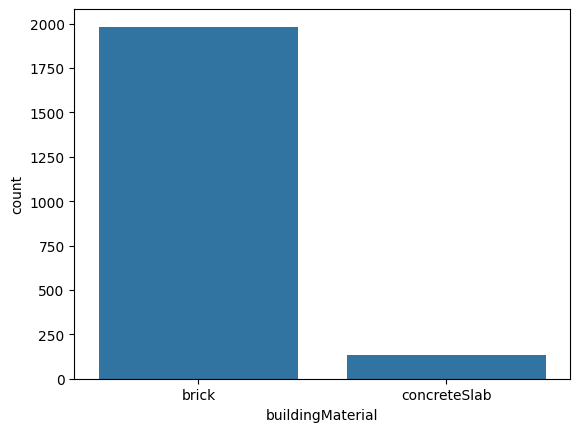

In [70]:
sns.countplot(data = df_wawa, x = 'buildingMaterial')

Widć wyraźną przewagę w danych mieszkań wykonanych w technologii: 'brick'.

Ponadto na podstawie heatmap należy podkreślić jednoznaczną i najwyższą korelacje brakujących danych pomiedzy "buildingMaterial" oraz "type" = 0.7.

Ilość danych = '*concreteSlab*' w kolumnie '*buildingMaterial*' jest znikoma, stanowią około 4%

Dlatego w toku dalszej analizy podjęto decyzję o imputacji brakujących danych (NaN) w columnie 'buildingMaterial' z wykorzystaniem imputacji losowej **Hot_Deck**, która powinna zachować rozkład danych, mając na uwadze, że braki są losowe.

In [71]:
df_wawa[df_wawa['buildingMaterial'] == 'concreteSlab']['type'].value_counts()



,count
type,
blockOfFlats,110
apartmentBuilding,17
tenement,5


In [72]:
# Imputacja losowa Hot Deck, definicja funkcji
def random_hot_deck_imputation(df, column):
    # Filtrujemy wartości nie-null
    non_null_values = df[column].dropna().values
    # Zastępujemy NaN losową wartością z istniejących
    df[column] = df[column].apply(lambda x: np.random.choice(non_null_values) if pd.isna(x) else x)
    return df

# Imputacja dla kolumny 'buildingMaterial'
df_titanic = random_hot_deck_imputation(df_wawa, 'buildingMaterial')
df_wawa['buildingMaterial'].isna().sum()

np.int64(0)

Ponownie badamy ilość poszczególnych typów danych w kolumnie *buildingMaterial*.

Widać znaczący wzrost ilości danych 'brick' oraz prawie niezauważalny wzrost danych 'concreteSlab'.

<Axes: xlabel='buildingMaterial', ylabel='count'>

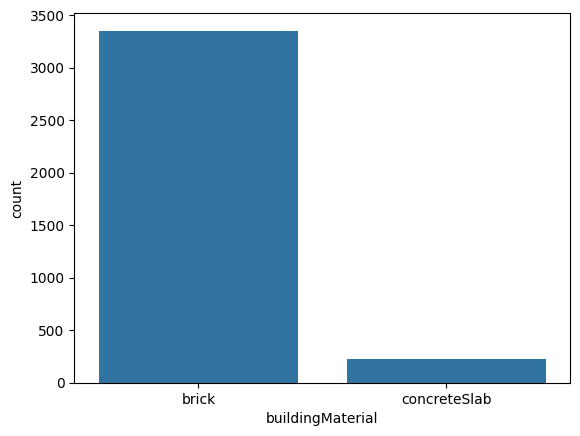

In [73]:
sns.countplot(data = df_wawa, x = 'buildingMaterial')

Ilość danych = 'concreteSlab' w kolumnie '*buildingMaterial*' wzrosła nieznacznie ale dalszym ciągu jest znikoma, stanowią około 6% co nie wpłynęło znacąco na rozkład danych

In [74]:
df_wawa[df_wawa['buildingMaterial'] == 'concreteSlab']['type'].value_counts()

,count
type,
blockOfFlats,140
apartmentBuilding,43
tenement,39


###4. Imputacja dla '*buildYear*'
wykonamy imputacja mediany grupowanej po 'type', tzn wyliczymy medianę z 'buildYear' dla różnych 'type'.

In [75]:
median_apartments   = df_wawa.loc[df_wawa['type'] == 'apartmentBuilding', 'buildYear'].median()
median_tenement     = df_wawa.loc[df_wawa['type'] == 'tenement', 'buildYear'].median()
median_blockOfFlats = df_wawa.loc[df_wawa['type'] == 'blockOfFlats', 'buildYear'].median()

print(f"apartments:   {median_apartments:}")
print(f"tenement:     {median_tenement:}")
print(f"blockOfFlats: {median_blockOfFlats:}")




apartments:   2010.0
tenement:     1950.0
blockOfFlats: 1999.0


Następnie zastepujemy wartosci NaN w '*buildYear*' zmiennymi z wyliczoną wartoscią mediany dla danego typu mieszkania

In [76]:
df_wawa.loc[(df_wawa['type'] == 'apartmentBuilding') & df_wawa['buildYear'].isna(), 'buildYear'] = median_apartments
df_wawa.loc[(df_wawa['type'] == 'tenement') & df_wawa['buildYear'].isna(), 'buildYear'] = median_tenement
df_wawa.loc[(df_wawa['type'] == 'blockOfFlats') & df_wawa['buildYear'].isna(), 'buildYear'] = median_blockOfFlats

df_wawa[['type','buildYear']].head(20)

,type,buildYear
0,tenement,1939.0
1,apartmentBuilding,2008.0
2,tenement,1875.0
3,blockOfFlats,2000.0
4,tenement,1950.0
5,tenement,1932.0
6,apartmentBuilding,2003.0
7,apartmentBuilding,1903.0
8,apartmentBuilding,2009.0
9,apartmentBuilding,2016.0


###5. Imputacja kolumny '*floor*'
Ponieważ kolumny '*floor*' jest zależna od '*floorCount*' tzn. '*flor*' musi być zawsze mniejsze od '*florCount*'. Zastosujemy imputację kolumny '*flor*' wartoscią średnią z '*florCount*' z ograniczeniem '*floor*' ≤ '*floorCount*'.

  Warto zauważyć, że '*floorCount*'ma bardzo mały ubytek danych i nie będzie podlegała imputacji.

In [77]:
# Wylicz średnią 'floor' w grupach wg 'floorCount'
df_wawa['floor'] = df_wawa['floor'].fillna(df_wawa.groupby('floorCount')['floor'].transform('mean'))
# Wszędzie gdzie floor >= floorCount — zastąp wartością floorCount - 1
df_wawa.loc[df_wawa['floor'] >= df_wawa['floorCount'], 'floor'] = df_wawa['floorCount'] - 1

# Jeśli w tych samych wierszach 'floor' oraz 'floorCount' występuję NaN, to uzupełniamy 'floor' na podstawie najbliżsej wartosci poprzedzającej lub nastepującej po danej.
df_wawa['floor'] = df_wawa['floor'].ffill()
df_wawa['floor'] = df_wawa['floor'].bfill()

# Zaokrąglenie do jednego miejsca po przecinku, nie zmienamy typu danych
df_wawa['floor'] = df_wawa['floor'].astype(float).round(1)

df_wawa[['floor','floorCount']].head(20)



,floor,floorCount
0,2.0,3.0
1,6.0,15.0
2,3.0,4.0
3,2.0,3.0
4,2.0,3.0
5,1.0,3.0
6,1.0,3.0
7,2.0,3.0
8,9.0,12.0
9,4.0,6.0


Weryfikujemy skuteczność przyjętej metody imputacji.

In [78]:
df_wawa[['floor','floorCount']].isna().sum()

,0
floor,0
floorCount,52


Poniżej DataFrame po realizacji Data Wrangling'u.

In [79]:
df_wawa.head(20)

,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,...,collegeDistance,pharmacyDistance,ownership,buildingMaterial,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,warszawa,tenement,39.80,2.0,2.0,3.0,1939.0,52.216513,21.041474,3.09,...,1.635,0.948,condominium,brick,no,no,no,no,no,3650
1,warszawa,apartmentBuilding,78.00,3.0,6.0,15.0,2008.0,52.245300,20.977900,2.31,...,0.569,0.184,condominium,brick,yes,yes,yes,no,no,5600
2,warszawa,tenement,82.00,3.0,3.0,4.0,1875.0,52.229151,20.990837,0.91,...,1.237,0.132,condominium,brick,no,no,NaN,no,no,6500
3,warszawa,blockOfFlats,89.00,4.0,2.0,3.0,2000.0,52.322375,20.937528,11.04,...,1.414,0.283,condominium,brick,yes,no,no,yes,yes,4500
4,warszawa,tenement,45.23,2.0,2.0,3.0,1950.0,52.238990,21.076190,5.01,...,0.264,0.129,condominium,brick,no,yes,no,no,no,3000
5,warszawa,tenement,50.00,3.0,1.0,3.0,1932.0,52.225329,21.034436,2.22,...,1.111,0.147,condominium,brick,no,yes,no,no,no,3750
6,warszawa,apartmentBuilding,70.00,3.0,1.0,3.0,2003.0,52.201553,20.958403,4.55,...,1.580,0.152,condominium,brick,yes,yes,yes,no,no,4500
7,warszawa,apartmentBuilding,68.00,3.0,2.0,3.0,1903.0,52.252914,21.033938,3.14,...,0.522,0.014,condominium,brick,no,no,no,no,no,5000
8,warszawa,apartmentBuilding,79.00,3.0,9.0,12.0,2009.0,52.207391,20.964526,3.79,...,0.839,0.066,condominium,brick,yes,yes,yes,no,no,5900
9,warszawa,apartmentBuilding,62.00,3.0,4.0,6.0,2016.0,52.227043,20.955604,3.31,...,0.688,0.108,condominium,brick,yes,yes,yes,no,no,5000


oraz podsumowainie skutecznosci imputacji danych wg przyjetych założeń.

In [80]:
df_wawa.isna().sum()

,0
city,0
type,0
squareMeters,0
rooms,0
floor,0
floorCount,52
buildYear,0
latitude,0
longitude,0
centreDistance,0


**Wnioski końcowe z Data Wrangling.**
W zadaniu skupiłem się na analizie danych pod kontem ich braku (NaN) oraz wykonaniu imputacji danych z wykorzystaniem róznych metod lub ich prostego uzupełnienia.

W mojej ocenie dobrze sprawdziła sie imputacja danych w oparciu obserwacje zalezności pomiędzy danymi w różnych kolumnach w szczególnosci metoda imputacji losowej nie wpłynęła znacząco na rozkład danych.


#**Wizualizacja i analiza danych**

W tej części przejdziemy do analizy oraz wizualizacji danych z wykorzystaniem bibliotek Python: **Matplotlib**, a w szczególności zbioru funkcji pyplot oraz **Seaborn**.

Poniżej wykres typu histogram prezentujący rozkład wartość wynajmu 'price'.

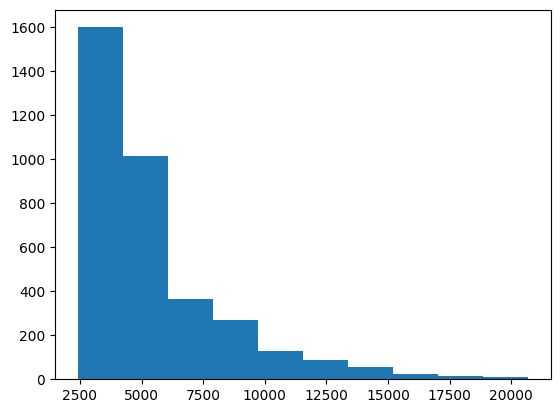

In [81]:
price_hist = plt.hist(df_wawa['price'])

* Wysokość każdego przedziału odzwierciedla liczbę obserwacji w tym przedziale.
* Zwiększanie lub zmniejszanie liczby przedziałów zapewnia większą lub mniejszą szczegółowość rozkładu.

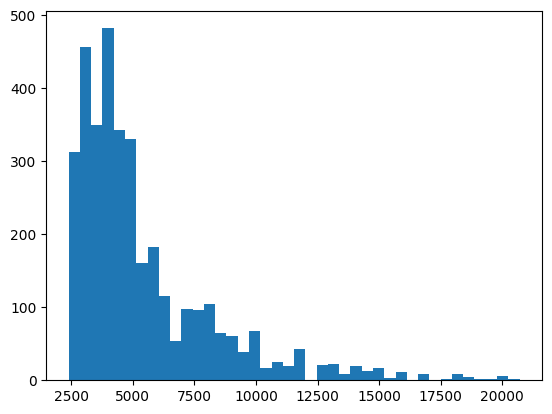

In [82]:
price_hist = plt.hist(df_wawa['price'], bins=40)

Poniżej taki sam histogram z wykorzystaniem biblioteki Seaborn.
Jak widać wykres jest czytelniejszy co skłania do korzystania z biblioteki Seaborn, która moim zdaniem prezentuje dane w sposób bardziej czytelny i jest ... ładniejsza 😊

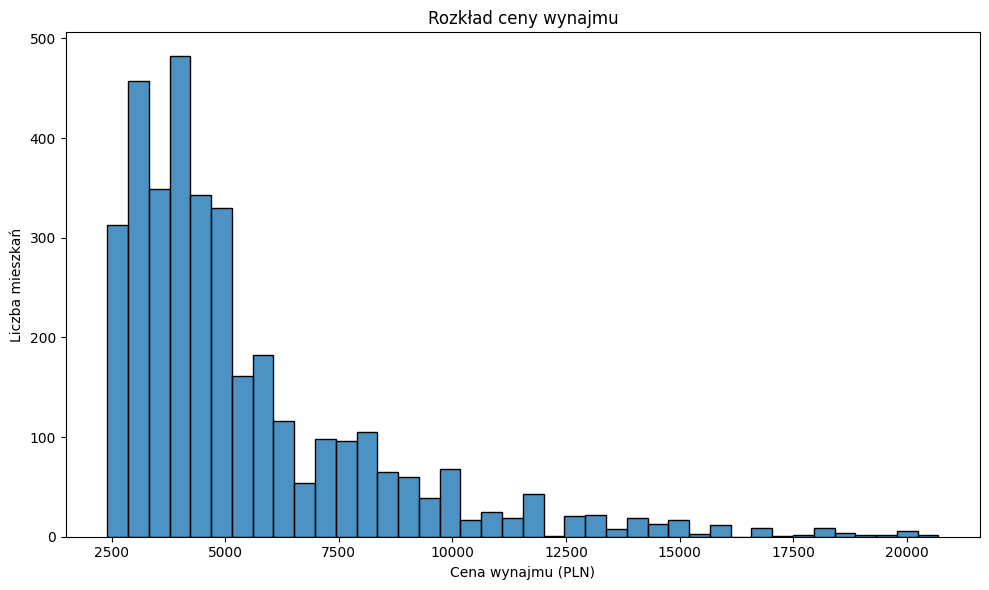

In [83]:

plt.figure(figsize=(10, 6))
sns.histplot(data = df_wawa, x = 'price', bins = 40, alpha = 0.8);

# Opisy osi
plt.xlabel('Cena wynajmu (PLN)');
plt.ylabel('Liczba mieszkań');
plt.title('Rozkład ceny wynajmu');

plt.tight_layout();
plt.show();


Poniżej dodatkowo prezentuje podstawowe statystyki opisowe dla '*price*'

In [84]:
df_wawa['price'].describe()

,price
count,3575.000000
mean,5447.822098
std,2959.907065
min,2400.000000
25%,3500.000000
50%,4500.000000
75%,6500.000000
max,20700.000000


Z porównania danych z describe: wartość średniej (544.82)  z  medianą (50%) (4500).
Średnia leży 948 PLN powyżej mediany. Skoro średnia daje się "ciągnąć w górę", a mediana nie — znaczy to, że w zbiorze jest grupa drogich ofert tworzących długi ogon w prawo. To liczbowe potwierdzenie **skośności prawostronnej**.

Na histogramie widać to samo: masa słupków skupiona po lewej (tańsze mieszkania), długi cienki ogon ciągnący się w prawo (drogie).

Przeanalizujmy teraz odległości od mediany:

w dół do minimum: 4500 − 2400 = 2 100 PLN
w górę do maksimum: 20700 − 4500 = 16 200 PLN

Ogon górny jest prawie 8 razy dłuższy niż dolny. Rozkład jest "przyklejony" do dołu (ceny nie schodzą poniżej 2400) i mocno rozciągnięty w górę. To klasyka rynku najmu — jest twarda dolna granica opłacalności, ale górnej granicy praktycznie nie ma.

Dodatkowo aby zwizualizować na histogrami ww. spostzreżenia dołużmy do niego linie prezentujące wartości śreniej oraz mediany

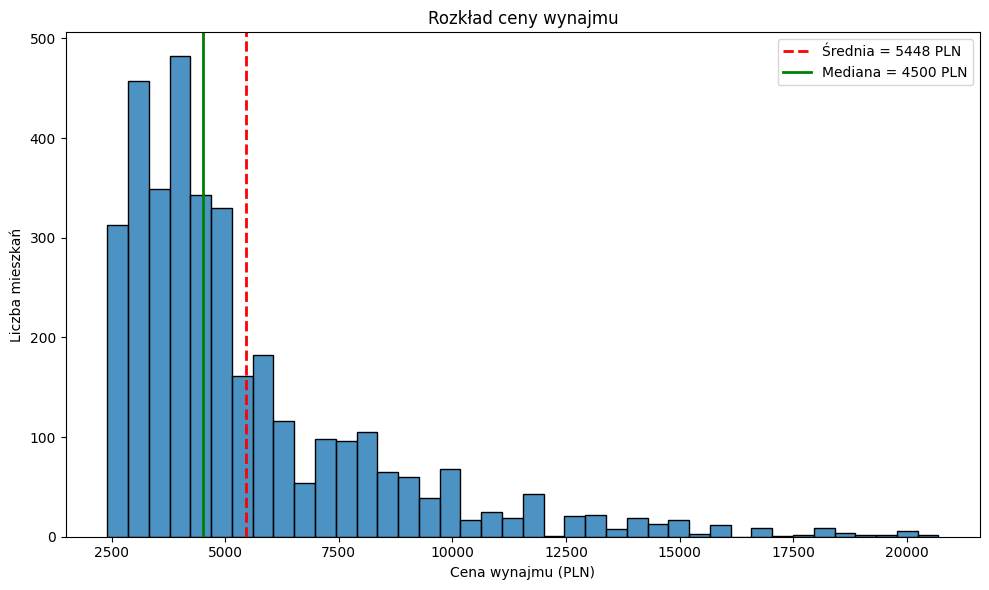

In [85]:
# Wyliczenie średniej i mediany
srednia = df_wawa['price'].mean()
mediana = df_wawa['price'].median()

# Histogram Seaborn
plt.figure(figsize=(10, 6))
sns.histplot(data=df_wawa, x='price', bins=40, alpha=0.8)

# Nałożenie pionowych linii: średnia i mediana
plt.axvline(srednia, color='red',   linestyle='dashed', linewidth=2,
            label=f'Średnia = {srednia:.0f} PLN')
plt.axvline(mediana, color='green', linestyle='-',  linewidth=2,
            label=f'Mediana = {mediana:.0f} PLN')

# Opisy osi
plt.xlabel('Cena wynajmu (PLN)');
plt.ylabel('Liczba mieszkań');
plt.title('Rozkład ceny wynajmu');
plt.legend()
plt.tight_layout();
plt.show();

Można również stworzyć histogram, który zliczone ilości poszczególnych wartości zmiennej ciągłej 'price' tak aby sumowały sie do 100%.

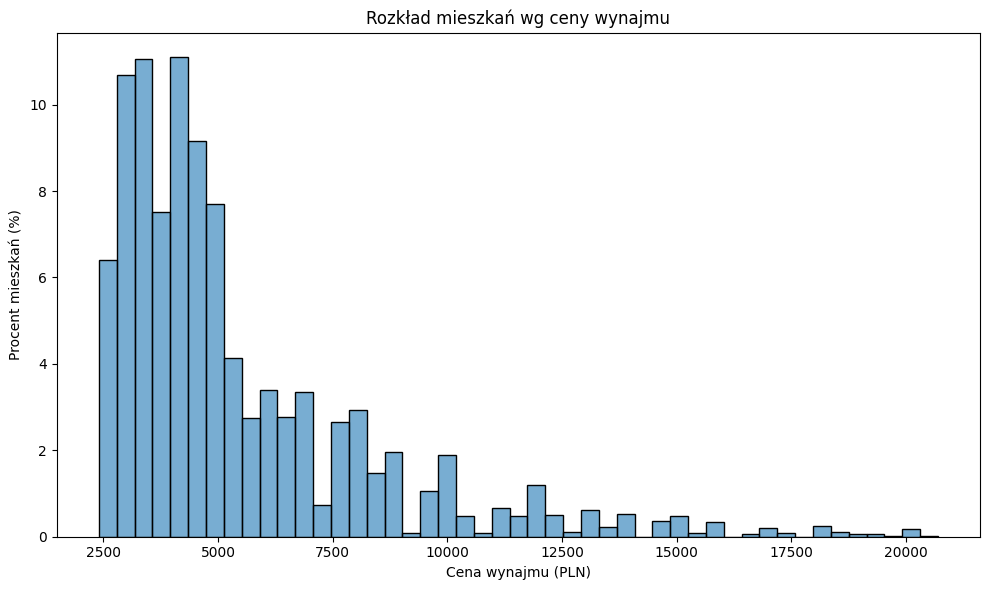

In [86]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_wawa, x='price', stat='percent', alpha=0.6)

plt.xlabel('Cena wynajmu (PLN)')
plt.ylabel('Procent mieszkań (%)')
plt.title('Rozkład mieszkań wg ceny wynajmu')
plt.tight_layout()
plt.show()

Ale znacznie lepiej takie sumowanie do 100% wygląda dla zmiennej dyskretnej.

Stworzymy wykres, który zliczone ilości poszczególnych typów danych tak aby sumowały sie do 100%. Wykorzystajmy do tego dane zmiennej dyskretnej określającej  ilości pokoji 'rooms' oraz wykres couttplot, który lepiej definiuje zmienne dyskretne (1,2,3,4, itd).


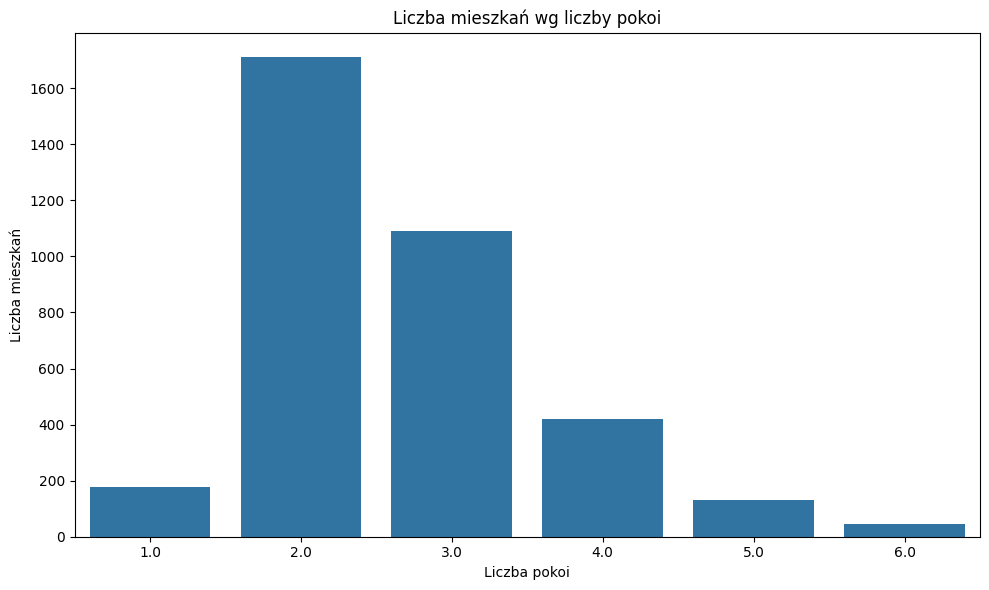

rooms
1.0     4.95
2.0    47.89
3.0    30.46
4.0    11.78
5.0     3.64
6.0     1.29
Name: proportion, dtype: float64


In [87]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_wawa, x='rooms')

plt.xlabel('Liczba pokoi')
plt.ylabel('Liczba mieszkań')
plt.title('Liczba mieszkań wg liczby pokoi')
plt.tight_layout()
plt.show()

# Procentowy udział każdej liczby pokoi
udzial = df_wawa['rooms'].value_counts(normalize=True).sort_index() * 100

# sort_index() porządkuje wynik rosnąco wg liczby pokoi (1, 2, 3...) zamiast wg częstości. Dzięki temu tabelka czyta się naturalnie.
# Bez tego value_counts() sortuje malejąco wg liczebności.

# Wyświetleniewyników z zaokrągleniem do 2 miejsc poprzecinku
print(udzial.round(2))

Jak widać na powyższym wykresie największy udział procentowy maja mieszkania 2 pokojowe.

Przeanalizujemy teraz zależność pomiędzy dwoma zmiennymi ciągłymi w opariu o wykres rozrzutu **scatterplot**

W analizowanym zbiorze danych najbardziej naturalne pary do zbadania zależności od price to:

* squareMeters vs price (metraż a cena, spodziewamy się dodatniej zależności)
* centreDistance vs price (odległość od centrum a cena, spodziewamy się ujemnej — dalej = taniej).

To zmienne o wielu unikalnych wartościach, więc chmura punktów będzie czytelna.

Skupmy się na analizie tej pierwszej pary zmiennych.


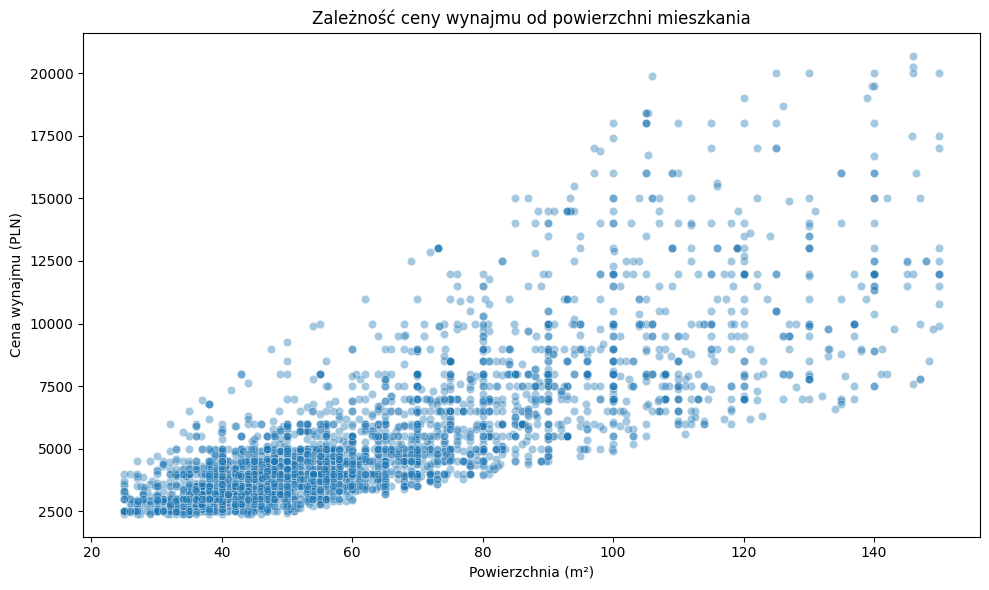

In [88]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_wawa, x='squareMeters', y='price', alpha=0.4)

plt.xlabel('Powierzchnia (m²)')
plt.ylabel('Cena wynajmu (PLN)')
plt.title('Zależność ceny wynajmu od powierzchni mieszkania')
plt.tight_layout()
plt.show()

Dolużmy do tego trzecią zmienną kategoryczną (dyskretną), która będzie nam dodatkowo  określała ilość pokoji 'rooms'.

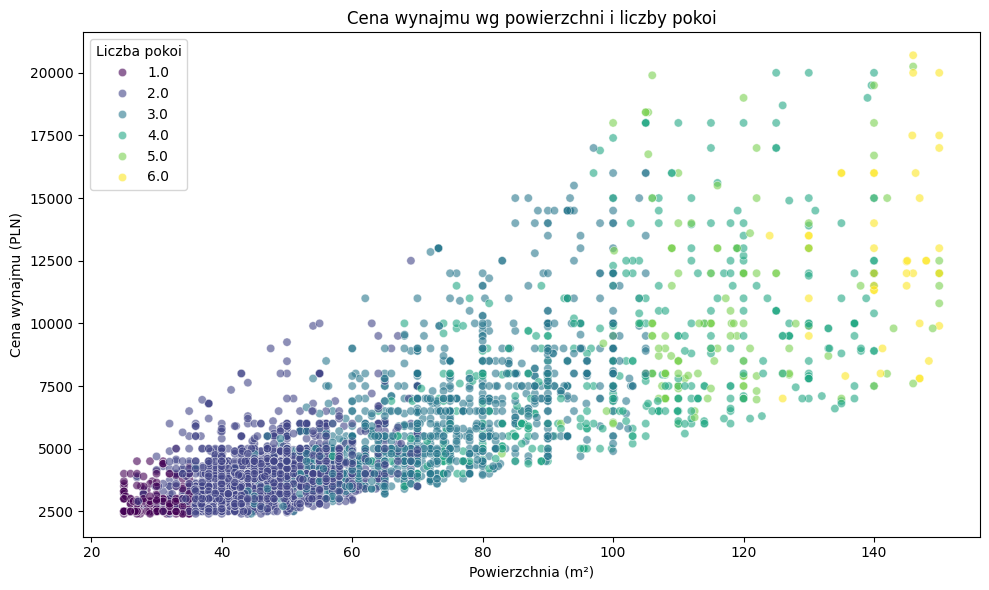

In [89]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_wawa,
    x='squareMeters',
    y='price',
    hue='rooms',
    palette='viridis',   # paleta sekwencyjna 1→6 te kolorki podobały mi się najbardziej
    alpha=0.6
)

plt.xlabel('Powierzchnia (m²)')
plt.ylabel('Cena wynajmu (PLN)')
plt.title('Cena wynajmu wg powierzchni i liczby pokoi')
plt.legend(title='Liczba pokoi')
plt.tight_layout()
plt.show()

Punkty  układają się w schodkowe pasma, mieszkania z małą liczbą pokoi (ciemne) skupione w lewym dolnym rogu (mały metraż, niska cena), a wraz ze wzrostem liczby pokoi (jaśniejsze) chmura przesuwa się w prawo i w górę.

To potwierdziłoby, że *rooms* i *squareMeters* są ze sobą silnie skorelowane (co logiczne — więcej pokoi = większy metraż), a obie razem wpływają (windują) na cenę.

Sprawdźmy jeszzce jak układają się dane ciągłe na osi czasu.

W tym celu sporzadzimy wykres lineplot dla: 'price' vs 'buildYear'. To bardzo dobra para dla lineplota, bo buildYear jest naturalnie uporządkowana (oś czasu), a to właśnie warunek, w którym lineplot działa najlepiej.

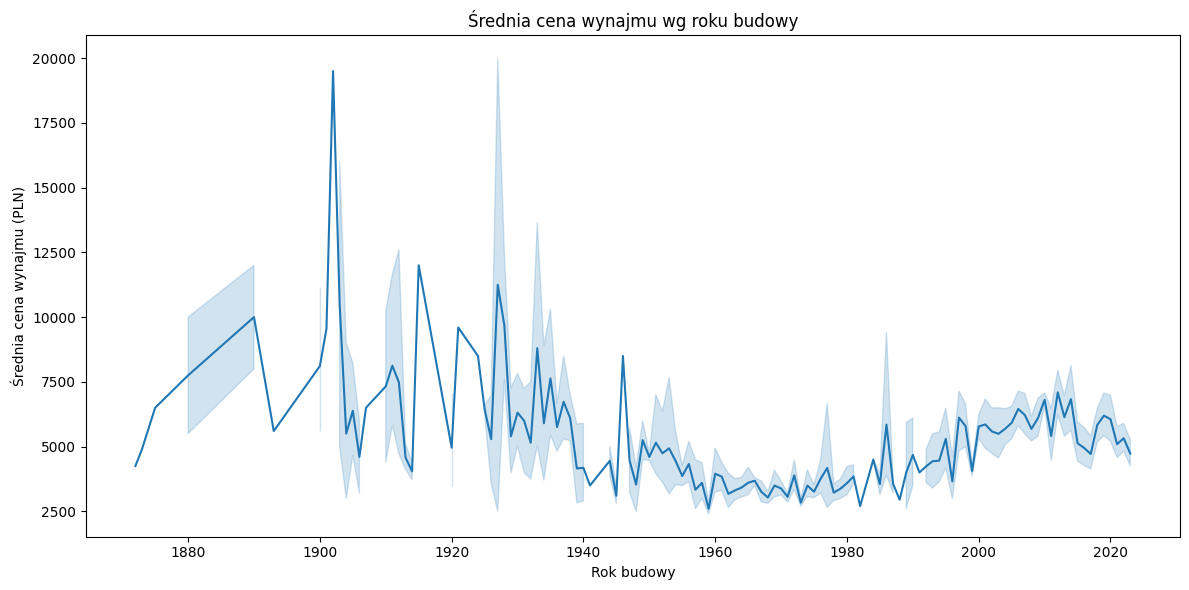

In [90]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_wawa, x='buildYear', y='price')

plt.xlabel('Rok budowy')
plt.ylabel('Średnia cena wynajmu (PLN)')
plt.title('Średnia cena wynajmu wg roku budowy')
plt.tight_layout()
plt.show()

Linia to średnia cena dla każdego roku, wstęga wokół niej to **95% przedział ufności**.

Na kształt wykresu ma wpły fakt, że imputowaliśmy buildYear medianą grupowaną po 'type'. To znaczy, że w danych powstały sztuczne "piki" — wszystkie mieszkania z brakującym rokiem dostały jedną z trzech wyliczonych wcześniej wartości mediany.

Na lineplocie widać w tych punktach nienaturalne skupienia i wąskie przedziały ufności. Tojest "ślad" po  imputacji.

Ważna uwafga: lineplot dla każdego roku policzy średnią cenę i wstęgę przedziału ufności. Przy starych latach, gdzie jest tylko kilka mieszkań, wstęga jest bardzo szeroka (duża niepewność), a linia skacze.

Szeroka wstęga = mało danych lub duży rozrzut w danym roku. Wykres jest bardzo poszarpany właśnie przez lata z pojedynczymi obserwacjami.

Powyższy wykres jest mało czytelny i trudno na jego podstawie wskazać jakąś linie trendu. Zastosujmy więc, podobnie jak poniżej dla wykresu boxplot, podział osi czasu na 10-letnie interwały - dekady.

Lineplot wg dekady jest znacznie bardziej czytelniejszy — grupowanie po 10 lat wygładza szum z pojedynczych lat i daje wyraźniejszy trend. Wersja "po dekadzie" pokaże czysty trend. Zestawienie obu jest bardzo interesujące.


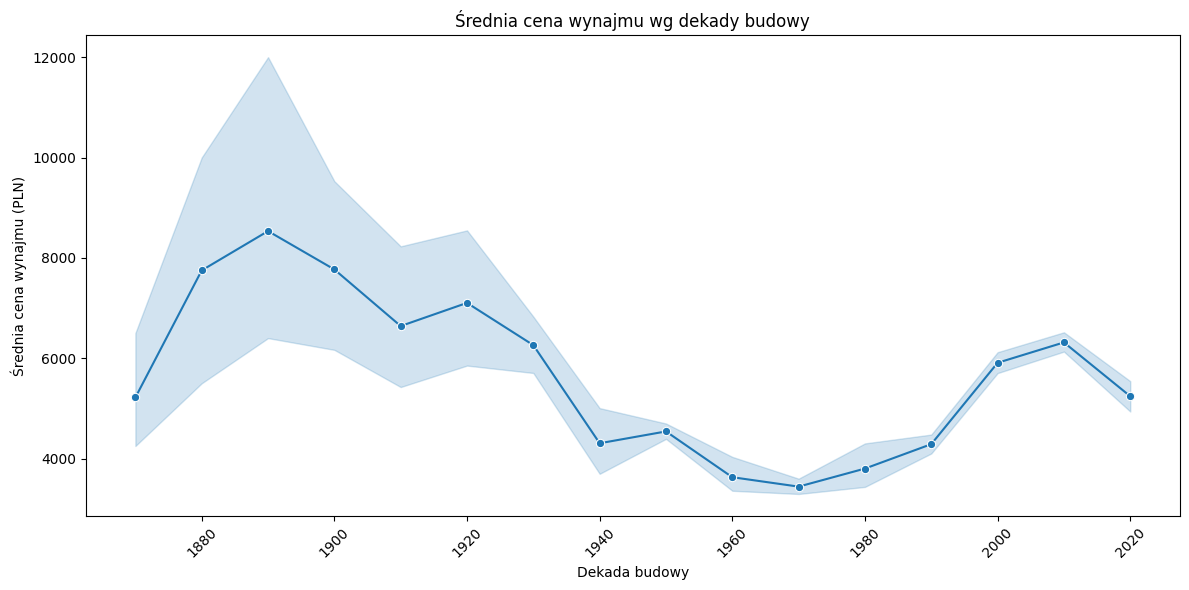

In [91]:
# Tworzenie kolumny z dekadami
df_wawa['dekada'] = (df_wawa['buildYear'] // 10 * 10).astype(int)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_wawa, x='dekada', y='price', marker='o')

plt.xlabel('Dekada budowy')
plt.ylabel('Średnia cena wynajmu (PLN)')
plt.title('Średnia cena wynajmu wg dekady budowy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###Wnioski z wykresów lineplot.

Wersja **"po roku"** (lineplot 1) jest poszarpana — mnóstwo ostrych pików sięgających 15 000–20 000 PLN i szerokie wstęgi przedziału ufności. To  ten szum, który omawialiśmy: pojedyncze lata (zwłaszcza przedwojenne kamienice) mają po kilka mieszkań, więc jedna droga oferta wywindowuje średnią całego roku, a przedział ufności robi się ogromny. Widać też ślad imputacji — sztuczne skupienia w niektórych punktach.

Wersja **"po dekadzie"** (lineplot 2) wygładza wspomniany szum i odsłania prawdziwy kształt w jaki układają się dane —  krzywą w kształcie litery U, a właściwie przypomina kształt asymetrycznej "**wanny**" :-)

Odczyt trendu — **krzywa "wanny"**

####Wykres z podziałem na dekady 'opowiada historię' budownictwa w warszawie:

* Najstarsze kamienice (1880–1890) — szczyt cenowy ~8 500 PLN. To prestiżowe przedwojenne budynki w centrum. Ale szeroka wstęgę ufności (od ~5 500 do ~12 000) wskazuje, że jest mało takich mieszkań i bardzo mają one różne ceny, więc średnia jest niepewna.

* Dno krzywej (1960–1970) — najniższe ~3 400 PLN. To era wielkiej płyty PRL: bloki z betonu, często poza centrum, najniżej cenione na rynku najmu. Wstęga jest tu wąska — dużo takich mieszkań, więc średnia jest pewna.

* Odbicie (2000–2010) — wzrost do ~6 300 PLN. Nowe budownictwo, apartamentowce, zamknięte osiedla — segment premium, który pojawia się również przy boxplotach.

* Lekki spadek po 2020 — może odzwierciedlać budownictwo na obrzeżach lub po prostu mniejszą próbę najnowszych budynków.

Poniżej wykres słupkowy prezentujący ilość różnych typów mieszkań na wynajem w Warszawie

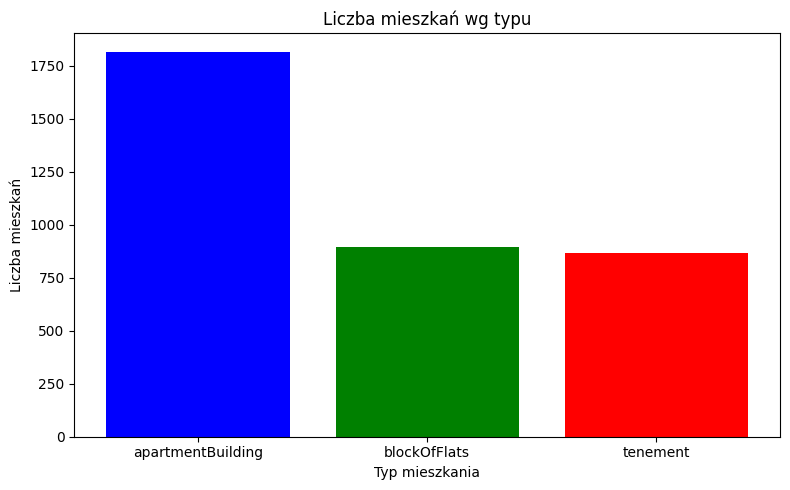

In [92]:
# Przypisanie danych do zmiennej
liczba = df_wawa['type'].value_counts()

#Rysowanie wykresu
plt.figure(figsize=(8, 5))
plt.bar(liczba.index, liczba.values, color=['blue', 'green', 'red'])

#Opis osi wykresu
plt.xlabel('Typ mieszkania')
plt.ylabel('Liczba mieszkań')
plt.title('Liczba mieszkań wg typu')
plt.tight_layout()
plt.show()

#Widac na nim wyraźną przewage mieszkań typu apartmentBuilding

Wykres słupkowy wyraźną przewagę ilości mieszkań typu apartmentBuilding, co może się wydawać naturalne w mieście takim jak Warszawa.

Poniżej wykres boxplot prezentujący zależność ceny '*price*' od typu wynajmowanego mieszkania: '*apartmentBuilding*', '*tenement*', '*blockOfFlats*'

<Figure size 1000x600 with 0 Axes>

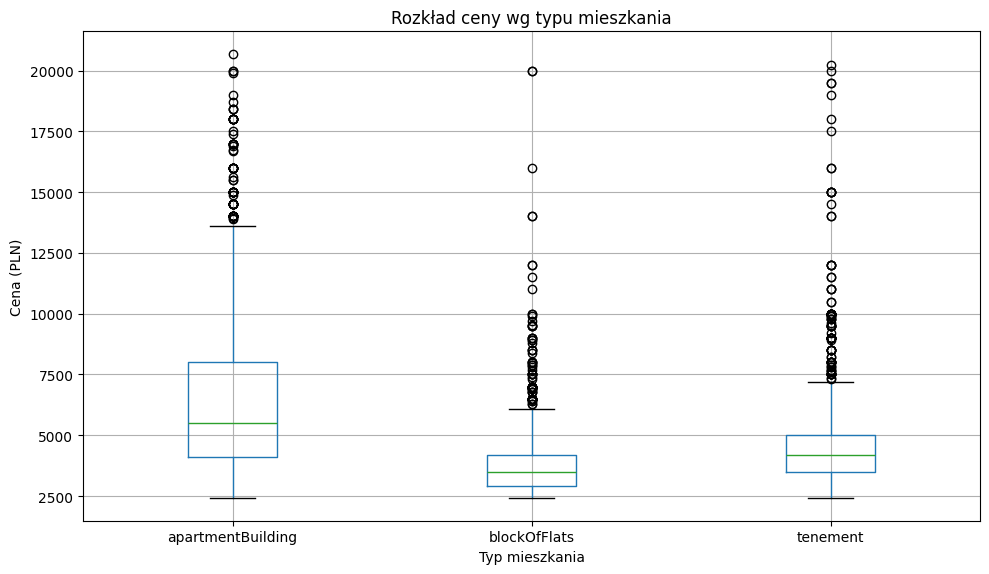

In [93]:
# Rysowanie wykresu
plt.figure(figsize=(10, 6))
df_wawa.boxplot(column='price', by='type', figsize=(10, 6))

# Opis osi wykresu
plt.xlabel('Typ mieszkania')
plt.ylabel('Cena (PLN)')
plt.title('Rozkład ceny wg typu mieszkania')
plt.suptitle('')
plt.tight_layout()
plt.show()



Wykres boxplot, prezentujący zależność ceny '*price*' od typu wynajmowanego mieszkania: '*apartmentBuilding*', '*tenement*', '*blockOfFlats*'

Wszystkie trzy typy mieszkań na wykresie, w szczególności 'apartmentBuilding' wykazują skośność prawostronną i outliery w górze oraz brak outlierów na dole — to typowy wzorzec rynku nieruchomości gdzie istnieje segment luksusowy, a Warszawa jak wykazaliśmy na wykresie słupkowym jest  rynkiem zdominowanym przez 'apartmentBuilding.
Ponadto porównanie median wskazuje jednoznaczną hierarchię cenową: apartmentBuilding > tenement > blockOfFlats.

Natomiast porównuując IQR  można okreśić, który z typu wmieszkań jest najtrudniejszy do wyceny.  Szerokie pudełko = duże zróżnicowanie cen. Wąskie = rynek jednorodny. Mając to na uwadze można określić hierarchię pod względem łatwości wyceny: apartmentBuilding > tenement > blockOfFlats. Jeśli jednak uwzględnimy dość licznie występujące outliery to moim zdaniem najtrudniejsze do wyceny są tenement, gdzie rozrzut wartości jest największy.

Przy wyciąganiu wniosków z analizy ceny 'price' warto potraktować 'type' jako zmienną, która w istotny sposób wpływa różnice między medianami, które są duże i statystycznie uzasadnione. Jednocześnie szerokość pudełek, szczególnie dla tenement, sugeruje że sama przynależność do typu to za mało — potrzebne są dodatkowe zmienne np. buildYear, żeby dobrze wyjaśnić wariancję wewnątrz każdej kategorii.

Po uzupełnieniu podstawowych danych przygotowałem wykres wizualizujący zależność pomiędzy rokiem budowy mieszkania na wynajem a jego ceną.

Dla większej czytelności dane zostały ponownie przedstawione z podziałem na dekady. Powód jest identyczny jak wcześniej, grupowanie danych pozytywnie wpływa na czytelność i ich interpretację na wykresie.

<Figure size 1400x600 with 0 Axes>

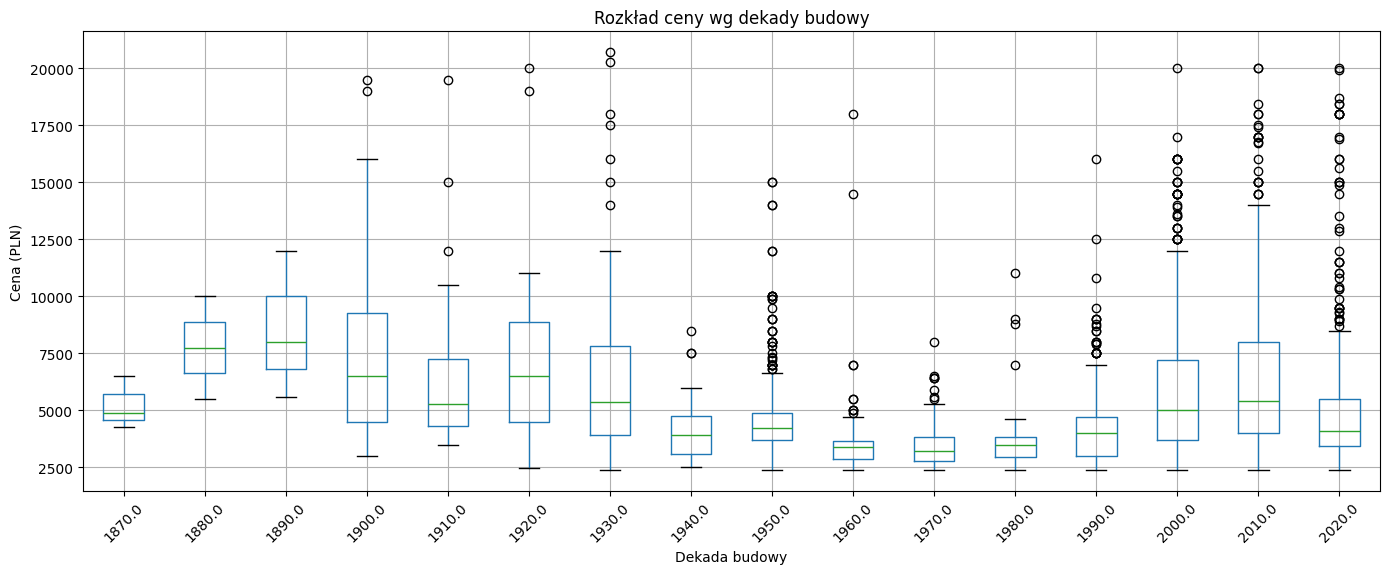

In [94]:
# Ponownie tworzenie kolumny z dekadami, tym razem dane są typu string
df_wawa['dekada_str'] = (df_wawa['buildYear'] // 10 * 10).astype(str)

# Tworzenie wykresu
plt.figure(figsize=(14, 6))
df_wawa.boxplot(column='price', by='dekada_str', figsize=(14, 6))

# Opisy osi wykresu itd.
plt.xlabel('Dekada budowy')
plt.ylabel('Cena (PLN)')
plt.title('Rozkład ceny wg dekady budowy')
plt.suptitle('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Wykres boxplot.
Przedsawiłem wzajemną korelację zalezności ceny '*price*' wynajmu od roku budowy '*buildYear*'.
Na podsatwie wykresu widac wyraźną zależność ceny mieszkania od roku jego budowy, przy czym wyraźny spadek wartości ceny wynajmu dotyczy  mieszkań zbudowanych w latach 1940 do 2000, najprawdopodobniej dotyczy to wielokondygnacyjnych budynków (bloków) zbudowanych w okresie PRL i znajdujących się po za centrum Warszawy.
Natomiast nowe budownictwo oraz stare kamienice, znajdujące się w centrum, co stanowi o ich atrakcyjności pod wynajem, zdecydowanie "trzymają" wysoką cenę.
W przypadku najnowszych mieszkań na wynajem widać wyraźną grupę outlier'ów, które stanowią luksusowe apartamenty wybudowane np. na z zamknietych osiedlach, ktorych wiele powastało w Warszawie po 2000 roku.


Dalasza analiza ceny '*price*' od innych czynników jak '*centreDistance*' lub '*buildYear*' może dostarczyć dodatkowych wniosków dotyczących czynników wpływających na cenę wynajmu mieszkania poza tak oczywistymi jak '*squareMeters*" czy '*rooms*'.

#**Analizy statystyk opisowych**

Zaczniemy od przyjrzenia się jak wygląda rozkład danych dla 'price'. Wcześniej opisywaliśmy go na podstawie wykresu a teraz obliczymy różne charalterystyki wartościowe dla tych danych. Zaczniemy od wyznaczenia wartości skośności.

Skośność to liczbowa miara asymetrii rozkładu — mówi, w którą stronę i jak mocno rozkład jest "przechylony". Jego sens jest prosty: mierzy, czy ogon rozkładu ciągnie się bardziej w prawo, czy w lewo.

In [95]:
skosnosc = df_wawa['price'].skew()
print(f'Skośność dla danych dotyczących price: {skosnosc:.3f}')

Skośność dla danych dotyczących price: 1.923


### Skala interpretacji skośności:

Przyjęte progi (reguła Bulmera) pomagają ocenić siłę asymetrii:

Wartość:
* |skośność| < 0,5	rozkład w przybliżeniu symetryczny
* 0,5 – 1,0	umiarkowanie skośny
* większe niż 1,0	silnie skośny

Nasz rozkłąd można więc określić jako **silnie skośny** i jak już pisałem wcześniej **prawostronny**.

Warto podkreślić, że skośność nie jest oderwaną liczbą, tylko łączy się z tym, co już policzylismy wcześniej, czyli średnią i medianą.
Jest zdefiniowana reguła, że dla rozkładu prawostronnie skośnego:  **średnia > mediana > moda (dominanta).**

Moda jest najczęściej występującą wartością w zbiorze danych.
Co znajduje potwierdzenie w naszych danych dla *price*.

In [96]:
srednia = df_wawa['price'].mean()
mediana = df_wawa['price'].median()
skosnosc = df_wawa['price'].skew()
moda = df_wawa['price'].mode()

print(f'Średnia:   {srednia:.0f} PLN')
print(f'Mediana:   {mediana:.0f} PLN')
print(f'Różnica:   {srednia - mediana:+.0f} PLN  (średnia > mediana → ogon w prawo)')
print(f'Skośność:  {skosnosc:.3f}')
print(f'Moda:      {moda}')

Średnia:   5448 PLN
Mediana:   4500 PLN
Różnica:   +948 PLN  (średnia > mediana → ogon w prawo)
Skośność:  1.923
Moda:      0    4000
Name: price, dtype: int64


Silna skośność ma realne konsekwencje dla dalszej analizy:

* Po pierwsze — mediana jest lepszą miarą "typowej ceny" niż średnia. Dokładnie dlatego w Data Wranglingu imputowalismy medianą, nie średnią.

* Po drugie — wiele klasycznych testów i modeli statystycznych zakłada rozkład zbliżony do normalnego. Przy skośności 1.923 to założenie jest nieprawdziwe.

W praktyce oznacza to, że jeśli później tworzylibyśmy model dla 'price', warto rozważyć transformację 'price' — np. transformację logarytmiczną, która "ściąga" długi ogon i przybliża rozkład do symetrycznego.

Jak wygląda skośność 'price' po potraktowaniu logarytmem?

In [97]:
skosnosc_price = df_wawa['price'].skew()
skosnosc_price_log = np.log(df_wawa['price']).skew()

print(f'Skośność price:        {skosnosc_price:.3f}')
print(f'Skośność log(price):   {skosnosc_price_log:.3f}')

Skośność price:        1.923
Skośność log(price):   0.753


Widać jak potraktowanie danych logarytmem potrafi ściągnąć skośność z ~1,9 do wartości 0,75 to typowa "sztuczka" przy danych o cenach z silną skośnością prawostronna.

Teraz omówimy **kwantyle** czyli pozycyjne, które dzielą uporządkowany zbiór danych na równe części. Wykorzystamy w tym celu funkcję .quantile z pakietu pandas.

In [98]:

# Mediana — kwantyl rzędu 0.5
print('Mediana (kwantyl 0.5):', df_wawa['price'].quantile(0.5))

# Kwartyle — 0.25, 0.5, 0.75
print('\n=== Kwartyle ===')
print(df_wawa['price'].quantile([0.25, 0.5, 0.75]))

# Decyle — od 0.1 do 0.9
print('\n=== Decyle ===')
decyle = df_wawa['price'].quantile([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
print(decyle)

Mediana (kwantyl 0.5): 4500.0

=== Kwartyle ===
0.25    3500.0
0.50    4500.0
0.75    6500.0
Name: price, dtype: float64

=== Decyle ===
0.1    2900.0
0.2    3300.0
0.3    3700.0
0.4    4000.0
0.5    4500.0
0.6    5000.0
0.7    5900.0
0.8    7020.0
0.9    9500.0
Name: price, dtype: float64


Na podstawie wyliczonych decyli widać jak "rozjeżdża się" górny ogon danych: różnica między D8 a D9 jest znacznie większa niż między D1 a D2, co jest liczbowym potwierdzeniem długiego ogona drogich mieszkań.

Na wartościach wyżej opisany wniosek przedstawia się następująco: na dole rozkładu decyle są stłoczone (300–500 PLN odstępu), a im wyżej, tym bardziej się rozjeżdżają — aż do 2 480 PLN między D8 a D9. Ostatni skok jest ponad 6× większy niż najgęstszy odstęp na dole.

Aby ww. dane były czytelne warto zastosować ponowenie wykres typu boxplot.
Boxplot to bezpośrednia wizualizacja kwartyli.

Pudełko rysuje się od Q1 do Q3, linia w środku to mediana (Q2), a wąsy i punkty odstające wynikają z IQR. Zrobimy go w seaborn.

Jak we wcześniejszych wykresach typu boxplot, użyłem y='price' (zamiast x), żeby pudełko było pionowe — przy cenach naturalnie czyta się "wysokość" jako wyższą wartość.

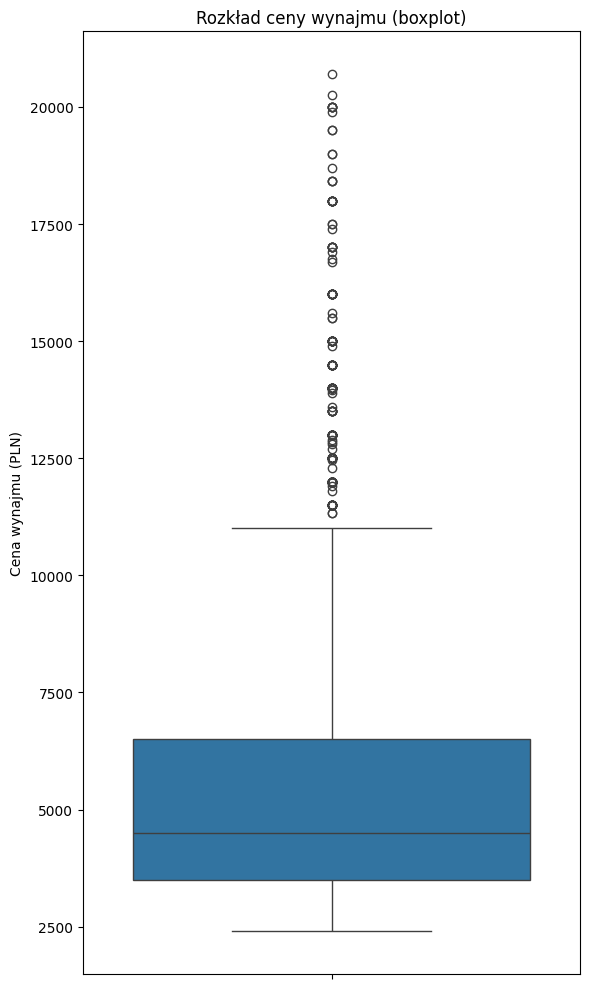

In [99]:
plt.figure(figsize=(6, 10))
sns.boxplot(data=df_wawa, y='price')

plt.ylabel('Cena wynajmu (PLN)')
plt.title('Rozkład ceny wynajmu (boxplot)')
plt.tight_layout()
plt.show()

Uzupełnimy ten bexplot o *.describe* i wyciągniemy wnioski.


In [100]:
df_wawa['price'].describe()

,price
count,3575.000000
mean,5447.822098
std,2959.907065
min,2400.000000
25%,3500.000000
50%,4500.000000
75%,6500.000000
max,20700.000000


* Q1 (0.25)  = 3 500 PLN   → dolna krawędź pudełka
* mediana    = 4 500 PLN   → linia w pudełku (bliżej dołu)
* Q3 (0.75)  = 6 500 PLN   → górna krawędź pudełka
* IQR        = 3 000 PLN   → wysokość pudełka
* górny wąs  = 11 000 PLN  → Q3 + 1,5×IQR
* outliery   > 11 000 PLN  → punkty aż do 20 700 PLN

Poddamy teraz analizie zmienność (rozproszenie), które opisuje jak wartości w rozkładzie są rozproszone, tj. różnią się od siebie. Będziemy badać paramerty takie jak wariancja, rozstęp międzykwartylowy (IQR) oraz odchylenie standardowe.


Wariancja i odchylenie standardowe bazują na średniej, więc dziedziczą jej wrażliwość na wartości skrajne. IQR bazuje na kwartylach, więc jest odporny — tak jak mediana. Przyjrzyjmy się temu dla 'price'.

In [101]:
wariancja = df_wawa['price'].var()
odch_std  = df_wawa['price'].std()
Q1 = df_wawa['price'].quantile(0.25)
Q3 = df_wawa['price'].quantile(0.75)
IQR = Q3 - Q1

print('=== Miary rozproszenia dla price ===')
print(f'Wariancja:          {wariancja:,.0f} PLN²')
print(f'Odchylenie stdandardowe:     {odch_std:,.0f} PLN')
print(f'Rozstęp międzykwartylowy (IQR): {IQR:,.0f} PLN')

=== Miary rozproszenia dla price ===
Wariancja:          8,761,050 PLN²
Odchylenie stdandardowe:     2,960 PLN
Rozstęp międzykwartylowy (IQR): 3,000 PLN


Ważna uwaga do wariancji,  pandas domyślnie liczy wariancję próby (dzieli przez n−1, tzw. korekta Bessela), a nie populacji (n). To poprawny wybór, gdy dane odpowiadają próbie z większej populacji. Co tu ma sens, bo 3575 badanych mieszkań to próbka rynku warszawskiego, nie cały rynek.

Do nszej analizy dorzućmy jeszcze współczynnik zmienności (std/średnia), który  wyraża rozrzut w procentach średniej, więc jest bezjednostkowy i pozwala porównywać rozrzut między zmiennymi o różnych skalach.

In [102]:
wsp_zmiennosci = df_wawa['price'].std() / df_wawa['price'].mean() * 100
print(f'Współczynnik zmienności: {wsp_zmiennosci:.1f}%')

Współczynnik zmienności: 54.3%


Dla price wyliczyliśmy współczynnik zmienności 54,3% — to bardzo duży rozrzut.

### Wnioski z analizy rozproszenia

1. Wariancja (8,7 miliona PLN²) jest praktycznie nieczytelna — "osiem milionów złotych do kwadratu" nic nie znaczy intuicyjnie.
2. Znacznie lepiej jest raportować i analizować odchylenie standardowe, nie wariancję. Pierwiastek z wariancji sprowadza liczbę z powrotem do złotówek: √8 761 050 ≈ 2 960 PLN.

3. Odch. std. ≈ IQR. Odchylenie standardowe (2 960) i IQR (3 000) wyszły niemal identyczne. Ale warto zaznaczyć, że każda z tych liczb mierzy co innego.

**Odchylenie standardowe** rozciąga się symetrycznie wokół średniej (5448 PLN). Formalnie sugeruje, że typowe ceny leżą w przedziale 5448 ± 2960, czyli od ~2 490 do ~8 410 PLN. Problem: dolna granica wypada blisko realnego minimum (2400), ale zakłada, że przedział jest symetryczny, co dla skośnych danych jest mylące. Rozkład wcale nie jest symetryczny wokół średniej.

**IQR** opisuje faktyczne środkowe 50% danych: od Q1 (3500) do Q3 (6500). Ten przedział jest "przesunięty" względem tego, co sugeruje odchylenie stanardowe, bo uczciwie podąża za asymetrią danych — nie zakłada ich symetrii.

### Przejdźmy teraz do analizy miary kształtu rozkład danych.

Kurtoza mierzy "grubość ogonów" rozkładu, czyli ile masy danych jest zgromadzonych w "ogonach" (wartościach skrajnych) w porównaniu z rozkładem normalnym. Potocznie można powiedzięć, że kurtoza bada "ogony" rozkładu i skłonność do produkowania wartości odstających.

pandas używa konwencji Fishera, tzn. od kurtozy odejmuje 3, żeby punktem odniesienia było 0. To wygodne i tego się trzymamy w dalszej części analizy. Wrócimy również do wyliczenia skośności aby dokonać analizy kształtu rozkładu dla '*price*'.

In [103]:
skosnosc = df_wawa['price'].skew()
kurtoza  = df_wawa['price'].kurtosis()

print('Analiza kształtu rozkładu price')
print(f'Skośność (skewness): {skosnosc:6.3f}  → silnie prawostronny')
print(f'Kurtoza  (kurtosis): {kurtoza:6.3f}  → leptokurtyczny (grube ogony)')


Analiza kształtu rozkładu price
Skośność (skewness):  1.923  → silnie prawostronny
Kurtoza  (kurtosis):  4.253  → leptokurtyczny (grube ogony)


W konwencji Fishera rozkład normalny ma kurtozę 0.

Wartość 4.253 jest znacznie powyżej zera, co oznacza ogony dłuższe niż w rozkładzie normalnym. 'price' produkuje o wiele więcej wartości skrajnych, niż przewidywałby rozkład normalny o tym samym odchyleniu standardowym. To liczbowe uzasadnienie dużej liczby outlierów, które widzieliśmy na boxplocie i tego rozjeżdżającego się górnego ogona z decyli.

Podsumowując, skośność wskazuje na "ogon po prawej", kurtoza mówi "ogon jest  długi". Razem opisują jednoznaczny rozkład silnie prawostronny, z wyraźnie zaznaczonym ogonem drogich apartamentów. Co ważne — obie liczby są zgodne kierunkowo z każdym wykresem i każdą miarą, którą policzyliśmy.

Do tej pory oceialiśmy normalność rozkładu albo na podstawie wykresów "na oko" (histogram, boxplot) albo badając miary kształtu rozkładu (skośność 1,923, kurtoza 4,253). To mocne poszlaki, ale test statystyczny daje obiektywną, formalną odpowiedź — zamiast "wygląda na skośny" mamy twardą decyzję opartą na liczbie.

Testy normalności działają w schemacie testowania hipotez:
* H0 (hipoteza zerowa):      dane POCHODZĄ z rozkładu normalnego
* H1 (hipoteza alternatywna): dane NIE pochodzą z rozkładu normalnego

Test zwraca p-value, które interpretujemy względem przyjętego poziomu istotności α (najczęściej 0,05):
* p-value > 0,05   →  brak podstaw do odrzucenia H0  →  rozkład MOŻE być normalny
* p-value ≤ 0,05   →  odrzucamy H0                    →  rozkład NIE jest normalny
### Wykonamy dwa testy: Shapiro-Wilka oraz D'Agostino-Pearsona.
Test **D'Agostino-Pearsona** łączy skośność i kurtozę w jeden test. Dobrze  pasuje do analizy, bo dokładnie te dwie miary wcześniej policzyliśmy. To on formalnie sprawdza, czy skośność i kurtoza są na tyle bliskie zeru, by uznać rozkład za normalny.

In [104]:
from scipy import stats

# Test D'Agostino-Pearsona (bazuje na skośności i kurtozie)
stat_dp, p_dp = stats.normaltest(df_wawa['price'])

# Test Shapiro-Wilka
stat_sw, p_sw = stats.shapiro(df_wawa['price'])

print('Testy normalności rozkładu price')
print(f"D'Agostino-Pearson:  statystyka = {stat_dp:.2f},  p-value = {p_dp:.3e}")
print(f"Shapiro-Wilk:        statystyka = {stat_sw:.2f},  p-value = {p_sw:.3e}")


Testy normalności rozkładu price
D'Agostino-Pearson:  statystyka = 1363.54,  p-value = 8.151e-297
Shapiro-Wilk:        statystyka = 0.80,  p-value = 1.133e-54


Oba p-value są "kosmicznie mniejsze" od progu 0,05 — nie o rząd czy dwa, ale o setki rzędów wielkości. To znaczy, że odrzucamy hipotezę H0 (o normalności) z absolutną pewnością. Prawdopodobieństwo, że tak skośne i leptokurtyczne dane pochodzą z rozkładu normalnego, jest praktycznie zerowe.

Warto docenić, że dwa niezależne testy, działające na różnych zasadach, dają ten sam werdykt:

Test D'Agostino-Pearson zbadał skośność i kurtozę → statystyka 1363,54, ekstremalnie wysoka.
Natomiast test Shapiro-Wilk zbadał ogólne dopasowanie do normalności → statystyka 0,80 (dla idealnie normalnych danych byłaby bliska 1,0)

Kiedy dwa różne testy zgadzają się tak mocno, wniosek jest pewny i co ważne obie liczby są w pełni spójne z tym, co policzyliśmy wcześniej.

Co brak normalności rozkładu oznacza praktycznie?

Jest to ważna cecha danych, która ma konkretne konsekwencje:

**Po pierwsze** — metody statystyczne zakładające normalność (test t, regresja liniowa w klasycznej postaci) mogą dawać zawodne wyniki na surowym 'price'. Jeśli budowalibyśy model, trzeba to uwzględnić.

**Po drugie** — warto w takich przypadkach dokonać transformacji danych z wykorzystaniem transformacji logarytmicznej,  o którym wspomnieliśmy przy skośności. log(price) zwykle drastycznie redukuje zarówno skośność, jak i kurtozę, przybliżając rozkład do normalnego.

Jako dodatkowe ćwiczenie zbadajmy więc pokrótce skośność, kurtozę i test normalności dla log(price) aby zobaczyć, jak bardzo się poprawiają.

In [105]:
import numpy as np
from scipy import stats

# Transformacja logarytmiczna danych
log_price = np.log(df_wawa['price'])

# Miary kształtu przed i po
print('=== Porównanie: price vs log(price) ===\n')
print(f"{'Miara':<20}{'price':>12}{'log(price)':>14}")
print('-' * 46)
print(f"{'Skośność':<20}{df_wawa['price'].skew():>12.3f}{log_price.skew():>14.3f}")
print(f"{'Kurtoza':<20}{df_wawa['price'].kurtosis():>12.3f}{log_price.kurtosis():>14.3f}")

# Test normalności dla log(price)
stat_dp, p_dp = stats.normaltest(log_price)
print(f"\nTest D'Agostino-Pearson dla log(price):")
print(f"  statystyka = {stat_dp:.2f},  p-value = {p_dp:.3e}")

=== Porównanie: price vs log(price) ===

Miara                      price    log(price)
----------------------------------------------
Skośność                   1.923         0.753
Kurtoza                    4.253         0.042

Test D'Agostino-Pearson dla log(price):
  statystyka = 272.39,  p-value = 7.107e-60


Jak logarytm wpłynął na metryki kształtu rozkładu danych?

Kurtoza to spektakularna zmiana spadła z 4,253 do 0,042, czyli praktycznie do zera. Wartość 0,042 jest o włos od idealnej normalnej (0). To znaczy, że logarytm niemal całkowicie zlikwidował problem długich ogonów. Ten rój odległych outlierów, który tak "napędzał" kurtozę, po transformacji przestał być odległy, logarytm ścisnął go do reszty rozkładu. Pod względem ogonów log(price) jest teraz właściwie nieodróżnialny od rozkładu normalnego.

Skośność też spadła znacząco z 1,923 do 0,753, czyli o ponad połowę. Przeszła z kategorii "silnie skośny" (>1) do "umiarkowanie skośny" (0,5–1). To duża poprawa, choć nie tak spektakularna jak przy kurtozie.

Podsumowując: transformacja logarytmiczna bardziej pomogła ogonom (kurtoza) niż asymetrii (skośność). To dlatego, że logarytm najsilniej działa na najbardziej odległe wartości a to właśnie one napędzały kurtozę.

Test normalności.
Formalnie test nadal odrzuca normalność (p wciąż dużo poniżej 0,05). Ale skala zmiany p-value: z e-297 na e-60. To poprawa o 237 rzędów wielkości! Choć rząd wielkości dalej jest "kosmiczny".

Rozkład jest nieporównanie bliższy normalnemu — statystyka testu spadła z 1363 do 272, czyli pięciokrotnie. Wprawdzie test wskazuje, że rozkład dalej nie jest normalny ale przy n = 3575 test jest tak czuły, że wychwytuje tę resztową skośność 0,753.

Wniosek, miary kształtu (zwłaszcza kurtoza ~0) i histogram jednoznacznie wskazują, że log(price) jest znacznie, znacznie bliższy normalności i nadaje się do metod, które przy zastosowaniu "surowego" price dałyby nieprawidłowe wyniki.

Liczby to jedno, ale najlepiej widać efekt na wykresach.

Zróbmy dwa histogramy w jednym rzędzie.

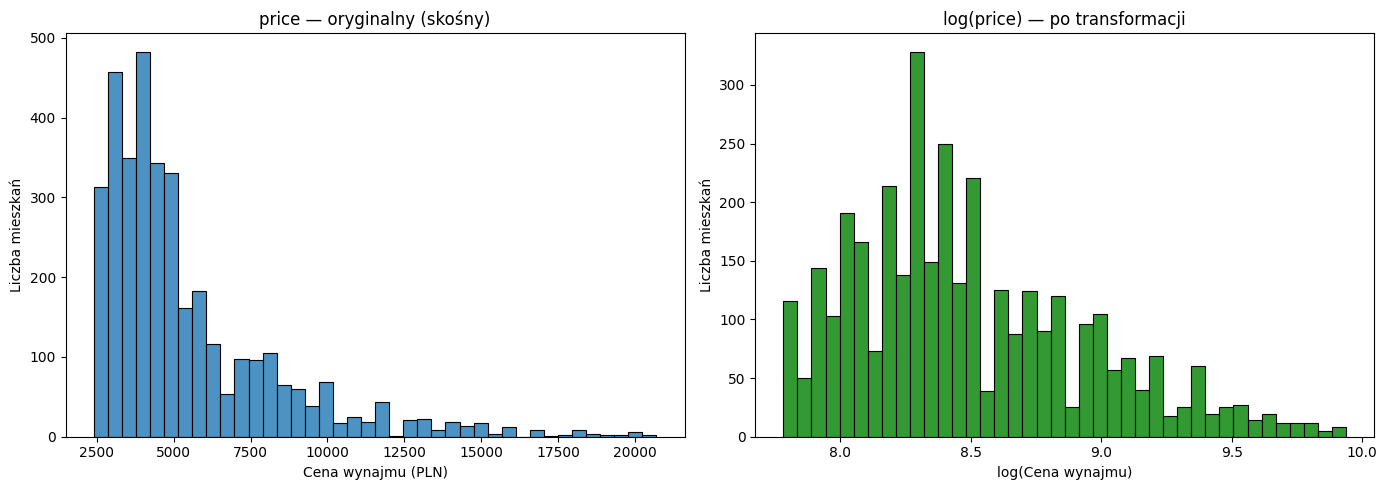

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram price (oryginalny)
sns.histplot(data=df_wawa, x='price', bins=40, alpha=0.8, ax=axes[0])
axes[0].set_title('price — oryginalny (skośny)')
axes[0].set_xlabel('Cena wynajmu (PLN)')
axes[0].set_ylabel('Liczba mieszkań')

# Histogram log(price) (po transformacji)
sns.histplot(data=df_wawa, x=log_price, bins=40, alpha=0.8, color='green', ax=axes[1])
axes[1].set_title('log(price) — po transformacji')
axes[1].set_xlabel('log(Cena wynajmu)')
axes[1].set_ylabel('Liczba mieszkań')

plt.tight_layout()
plt.show()

Histogram ilustruje oba wyniki, które omawialiśmy:

Kurtoza bliska 0. Widać to jako brak odległych, izolowanych słupków. W oryginale ogon ciągnął się samotnie do 20 000; po transformacji skrajne wartości są tuż obok reszty, ogony są krótkie. To właśnie ta kurtoza 0,042 — grube ogony zniknęły.

Resztowa skośność 0,753 Jak widać kształt  rozkładu nie jest idealnie symetryczny. Z prawej strony prawego wykresu widać wyraźny ogonek ciągnący się w prawo (te malejące słupki od 9,0 do 10,0). Lewa strona opada stromiej, prawa łagodniej. To jest ta niewielka skośność (0,753) uwidoczniona graficznie — logarytm naprostował rozkład mocno, ale nie perfekcyjnie. Dokładnie to wyszło z analizy miar: dane są bliskie log-normalnym, ale nie idealnie.

Mamy teraz komplet informacji o rozkładzie spójnych ze sobą w trzech obszarach:

* liczby: skośność 1,92→0,75, kurtoza 4,25→0,04
* test: p-value z e-297 do e-60 (poprawa o 237 rzędów)
* wykres: z jednostronnie skośnego "ogona" w dzwon z lekkim resztowym przechyłem

Wszystkie trzy jednoznacznie wskazują, że transformacja logarytmiczna dramatycznie poprawiła normalność, choć jej nie zapewniła idealnie. To  przykład, jak łączyć miary opisowe, test statystyczny i wizualizację, żeby wyrobić sobie pełny obraz analizowanych danych.

Ostatnim elementem naszej analizy będzie **badanie korelacji**.

Korelacja mierzy siłę i kierunek liniowego związku między dwiema zmiennymi numerycznymi. Współczynnik korelacji (Pearsona) przyjmuje wartości od −1 do +1:

* +1   idealna korelacja dodatnia (jedna rośnie → druga rośnie)
* 0   brak liniowego związku
* −1   idealna korelacja ujemna (jedna rośnie → druga maleje)

Korelacji Pearsona nie liczy się dla kategorii, tylko dla wartości liczbowych.\

Uwagi i zastrzeżenia do macierzy korelacji, o których trzeba pamiętać, żeby nie przeinterpretować macierzy:

**Po pierwsze**  — korelacja mierzy tylko związek liniowy. Dwie zmienne mogą być silnie powiązane w sposób nieliniowy (jak price vs buildYear (dekada) — gdzie wyszła nam w analizie krzywa 'wannowa'), a Pearson pokaże niską korelację, bo związek nie jest prostą linią. Wykres dekadowy to idealny przykład: cena najpierw spada, potem rośnie — korelacja liniowa to "spłaszczy" do wartości bliskiej zeru, mimo że związek istnieje.

**Po drugie** — korelacja to nie przyczynowość. Nawet silny współczynnik nie znaczy, że jedna zmienna powoduje drugą. Klasyczny przykład: rooms i squareMeters będą silnie skorelowane, ale to nie znaczy że pokoje "powodują" metraż — po prostu jedno i drugie odzwierciedla wielkość mieszkania.

**Po trzecie** — Pearson zakłada w miarę normalne rozkłady i jest wrażliwy na outliery. Wiemy, że 'price' jest silnie skośny z grubym ogonem, więc jego korelacje mogą być zaburzone przez te drogie apartamenty. Dlatego dla porównania zrealizowałem również korelacją rangową Spearmana, która jest mniej wrażliwe na wartości odstające i nie wymagają liniowości.

Na początku policzymy korealcją tylko dla 'price'.

Metoda .corr() liczy korelacje dla wszystkich par kolumn numerycznych.

In [107]:
# Wybieramy tylko kolumny numeryczne
kolumny_num = df_wawa.select_dtypes(include='number')

# Macierz korelacji Pearsona
macierz_kor = kolumny_num.corr()

# Korelacje z ceną, posortowane malejąco
print('Korelacja zmiennych z price')
print(macierz_kor['price'].sort_values(ascending=False).round(3))

=== Korelacja zmiennych z price ===
price                   1.000
squareMeters            0.788
rooms                   0.695
poiCount                0.150
longitude               0.124
dekada                  0.095
buildYear               0.086
kindergartenDistance    0.056
pharmacyDistance        0.003
floor                   0.001
postOfficeDistance     -0.040
floorCount             -0.040
schoolDistance         -0.051
latitude               -0.085
clinicDistance         -0.087
restaurantDistance     -0.094
collegeDistance        -0.121
centreDistance         -0.210
Name: price, dtype: float64


### Badanie wartości korelacji dla 'price' + wnioski

1. squareMeters z korelacją 0,788 to zdecydowanie najsilniejszy predyktor ceny — wpada w kategorię "bardzo silna". To liczbowe potwierdzenie chmury punktów, którą widać na scatterplo'cie: im większy metraż, tym wyższa cena, i związek jest wyraźnie liniowy.

2. rooms (0,695) wartość korelacji tuż za squareMeters, co nie dziwi mając na uwadze rozkład pasma kolorów na scatterplocie. Liczba pokoi i metraż to w dużej mierze ta sama informacja o wielkości mieszkania, tylko wyrażona inaczej.
Warto o tym pamiętać przy ewentualnym modelowaniu: te dwie zmienne są ze sobą silnie skorelowane (współliniowość), więc wrzucenie obu do modelu regresji może powodować problemy. Zwykle wybiera się jedną — tu naturalnie squareMeters, bo jest ciągła i silniejsza.

3. buildYear

    buildYear   0,086   → praktycznie zero!
    dekada      0,095   → prawie to samo
    Wiemy z całą pewnością, że rok budowy wpływa na cenę — widziałeś to na wykresie dekadowym jako wyraźną krzywą "wannową": wysokie ceny dla przedwojennych kamienic (około 8500 PLN), dołek dla bloków PRL (około 3400 PLN), odbicie dla nowego budownictwa (około 6300 PLN). Zależność jest ewidentna.

    A Pearson pokazuje 0,086 — czyli praktycznie brak związku. Dlatego, ze  korelacja Pearsona mierzy wyłącznie związek liniowy. Krzywa "wannowa" to związek nieliniowy: cena najpierw spada, potem rośnie. Najprawdopodobniej te dwa przeciwstawne trendy wzajemnie się znoszą przy dopasowywaniu prostej linii, więc współczynnik wychodzi bliski zeru mimo silnej rzeczywistej zależności.

4. centreDistance

    centreDistance   −0,210   → słaba/umiarkowana ujemna
    Kierunek się zgadza (dalej od centrum = taniej), ale siła jest mniejsza niż intuicja podpowiada. Prawdopodobne wyjaśnienie: w Warszawie są drogie lokalizacje poza ścisłym centrum (Wilanów, Mokotów, Żoliborz) oraz tańsze w bliskim sąsiedztwie centrum. Sama odległość geograficzna nie oddaje więc prestiżu dzielnicy. To ciekawy wniosek o warszawskim rynku.
    To najsilniejsza korelacja ujemna w całym zestawieniu — wśród zmiennych lokalizacyjnych właśnie ona najlepiej tłumaczy cenę.


Skoro 'price' jest skośny i nieliniowo związany z niektórymi zmiennymi, warto pokazać korelację Spearmana. Dlatego dodatkowo porównanie dwóch sposobów liczenia korelacji: Pearson i Spearman.

Spearman liczy korelację na rangach zamiast na surowych wartościach, dzięki czemu jest odporny na outliery i wychwyci związek, o ile jest monotoniczny (konsekwentnie rosnący lub malejący), nawet jeśli nie jest idealnie liniowy.

In [109]:
print('Pearson vs Spearman dla price')
pearson = kolumny_num.corr(method='pearson')['price']
spearman = kolumny_num.corr(method='spearman')['price']

porownanie = pd.DataFrame({'Pearson': pearson, 'Spearman': spearman}).round(3)
print(porownanie.sort_values('Spearman', ascending=False))

Pearson vs Spearman dla price
                      Pearson  Spearman
price                   1.000     1.000
squareMeters            0.788     0.801
rooms                   0.695     0.728
poiCount                0.150     0.142
dekada                  0.095     0.137
buildYear               0.086     0.113
longitude               0.124     0.110
kindergartenDistance    0.056     0.075
pharmacyDistance        0.003    -0.004
floor                   0.001    -0.021
postOfficeDistance     -0.040    -0.035
floorCount             -0.040    -0.037
schoolDistance         -0.051    -0.046
collegeDistance        -0.121    -0.086
clinicDistance         -0.087    -0.096
latitude               -0.085    -0.119
restaurantDistance     -0.094    -0.124
centreDistance         -0.210    -0.240


Ostatni element naszej analizy to **macierz korelacji**.

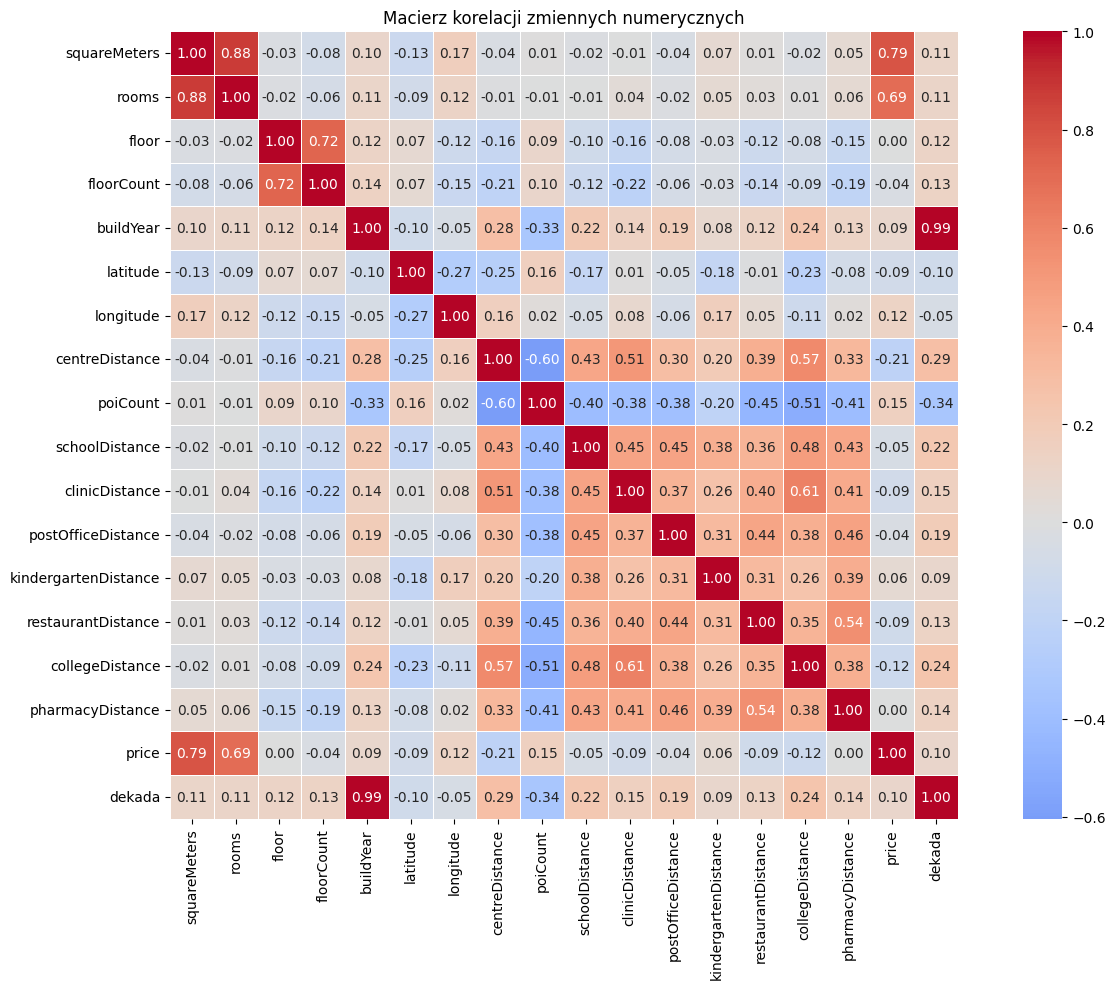

In [108]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    macierz_kor,
    annot=True,        # wpisuje wartości liczbowe w komórki
    fmt='.2f',         # dwie cyfry po przecinku
    cmap='coolwarm',   # niebieski (ujemne) → czerwony (dodatnie)
    center=0,          # zero = kolor neutralny (biały)
    square=True,
    linewidths=0.5
)
plt.title('Macierz korelacji zmiennych numerycznych')
plt.tight_layout()
plt.show()

###Macierz korelacji

ujawnia wiele zależności, których nie  było widać w samymbadaniu korelacji tylko z '*price*'.

**Wiersz 'price'**

squareMeters 0,79 i rooms 0,69 świecą na czerwono, reszta wiersza jest niemal bezbarwna. To wizualne potwierdzenie tego, co omawialiśmy: cenę tłumaczy przede wszystkim wielkość mieszkania, a pozostałe zmienne numeryczne w ujęciu liniowym niewiele wnoszą.

**Najciekawsze wnioski poza wierszem price**

Tu heatmapa pokazuje swoją wartość — widać związki między danymi których ranking z price nie ujawniał:

1. squareMeters ↔ rooms = 0,88 — bardzo silna współliniowość. To potwierdza to, o czym pisaliśmy: obie zmienne mierzą praktycznie to samo (wielkość mieszkania). Przy budowie modelu regresji wrzucenie obu naraz byłoby problematyczne — trzeba wybrać jedną.

2. floor ↔ floorCount = 0,72 — silny związek, ale uwaga: to prawdopodobnie w dużej mierze artefakt realizowanej imputacji. floor uzupełnialismy średnią w grupach floorCount. To tworzy zależność między tymi zmiennymi.

3. buildYear ↔ dekada = 0,99 — oczywiste i trywialne, bo dekada jest bezpośrednio wyliczona z buildYear. To zmienne redundantne, w modelu należy uzyć tylkko jednej z nich: buildYear.

4. centreDistance ↔ poiCount = −0,60 — bardzo sensowna zależność: im dalej od centrum, tym mniej punktów zainteresowania w okolicy. Logiczne odzwierciedlenie struktury miasta.

5. Prawy dolny blok macierzy: wszystkie zmienne dystansowe (schoolDistance, clinicDistance, postOfficeDistance, restaurantDistance, collegeDistance, pharmacyDistance) są ze sobą wzajemnie skorelowane na poziomie 0,26–0,61. Najsilniej clinicDistance ↔ collegeDistance (0,61) i restaurantDistance ↔ pharmacyDistance (0,54).
    To ma prosty sens: mieszkanie położone daleko od jednej instytucji jest zwykle daleko od wszystkich — bo znajduje się na peryferiach. Te zmienne mierzą w gruncie rzeczy jedną rzecz: "peryferyjność lokalizacji". Wszystkie korelują też dodatnio z centreDistance (0,20–0,57), co potwierdza nasze wnioski.

    Ciekawe jest to, że mimo tak wyraźnej korelacji zmiennych dystansowych, żadna z tych zmiennych nie koreluje z price (wszystkie w przedziale −0,12 do 0,06). Peryferyjność sama w sobie nie tłumaczy ceny w Warszawie — co wraca do wniosku o centreDistance, że sama odległość geometryczna nie oddaje prestiżu dzielnicy.


Heatmapa pokazała strukturę zależności między danymi. Dla samej analizy statystyk opisowych to ciekawostka, ale dla ewentualnego modelowania to kluczowa informacja. Są co najmniej  trzy grupy zmiennych redundantnych (squareMeters/rooms, buildYear/dekada, odległości do kluczowych instytucji ), które wymagałyby redukcji przed budową modelu.